# Exploratory Data Analysis

## ASEMIC
Recall the `ASEMIC` model proposed by Florian and Huber:
- Acquire Data
- Scrub Data
- Explore Data
- Model Data
- Interpret Results
- Communicate Results

This process was presented as a relatively linear process -- this is *rarely* the reality.

## Exploring Data, over and over and over

Instead of exploring our data in one stage, we will typically explore it throughout the entire pipeline, with different focus and depth

Examples:
- Acquire phase: checking classes and data types upon read-in
- Scrub phase: checking for outliers, typos, data quality
- Explore phase: checking statistical measures, shapes, propertise
- Model phase: checking leverage, multicollinearity
- Interpret phase: checking influential points or variables
- Communicate phase: lots and lots of data visualization

## Scrubbing

The Scrub stage of *ASEMIC* is usually called "Pre-Processing". This stage typically involves:

- Handling Missing Data: Filling or removing missing data entries to prevent errors in the analysis.
- Data Integration: Combining data from multiple sources to create a comprehensive dataset.
- Data Transformation: Normalizing, scaling, or converting data to ensure that the dataset has a consistent scale and format.
- Data Cleaning: Removing noise and correcting inconsistencies, which may involve addressing outliers, duplicate data, and correcting typos.
- Data Reduction: Reducing the complexity of data, for instance decreasing the number of features in a dataset, or modifying the dataset to focus on important attributes.


## Missing Data

Missing data is common!

Causes include:
- errors in data entry
- failures in data collection processes
- errors in data transmission


## Missing Data

There are two general approaches to handling missing data:
1. Remove it (deletion)
2. Fill in the missing values with guesses (imputation)

There are benefits and drawbacks to each of these approaches!

## Missing Data in Python

There are a few different ways that missing data are represented in Python
- 'None': general Python singleton representing missing values; used in general programming applications
- 'np.nan': "Not a Number" for missing OR undefined data in numpy applications (always a float-type value)
- 'pd.NA': missing values in pandas (maintains data type; e.g., boolean or integers)



In [ ]:
## Example Data

import pandas as pd
import numpy as np

# Create dummy data
data = {
    'Name': ["Alice", "Bob", "", "Diane"],
    'Age': [25, np.nan, 30, 28],
    'Salary': [50000, None, 60000, 52000],
    'Gender': ['Female', "", "", ""]
}
df = pd.DataFrame(data)

print("Original DataFrame:")
df.head()

Original DataFrame:


,Name,Age,Salary,Gender
0,Alice,25.0,50000.0,Female
1,Bob,NaN,NaN,
2,,30.0,60000.0,
3,Diane,28.0,52000.0,


In [ ]:
## DataFrame.info Method

# The .info method associated with Pandas DataFrames is quick and (mostly) reliable:
df.info()

# What are the problems with this output?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    4 non-null      object 
 1   Age     3 non-null      float64
 2   Salary  3 non-null      float64
 3   Gender  4 non-null      object 
dtypes: float64(2), object(2)
memory usage: 260.0+ bytes


In [ ]:
## DataFrame.eq Method

?pd.DataFrame.eq

In [ ]:
## .eq Method

print(df.eq(''))

print(df.eq('').sum())


    Name    Age  Salary  Gender
0  False  False   False   False
1  False  False   False    True
2   True  False   False    True
3  False  False   False    True
Name      1
Age       0
Salary    0
Gender    3
dtype: int64


## Missing Data - Deletion Strategies

There are three primary deletion strategies for handling missing values:
1. Listwise deletion: delete any observation/case with any missing values
   - Fast, simple
   - Can greatly reduce size/amount of data available
   - Can introduce bias to data
2. Pairwise deletion: delete observations with missing values...only if the analysis method requires complete cases
   - Convenient (requires little effort from us)
   - Can make results of analyses harder to interpret (or even invalidate results)
3. Column deletion: delete particularly offending columns
   - Can help to maintain data size and integrity (compared to listwise deletion)
   - Can potentially lose important information (for modeling or interpretation)


In [ ]:
## Example - Listwise Deletion

# Removing any rows that have at least one missing value -- kinda...
clean_df = df.dropna()
print("DataFrame after dropna():")
clean_df.head()


DataFrame after dropna():


,Name,Age,Salary,Gender
0,Alice,25.0,50000.0,Female
2,,30.0,60000.0,
3,Diane,28.0,52000.0,


In [ ]:
## Example - Listwise Deletion

# Create a mask to handle a string column
mask = [x not in ["", "unknown", "missing", "None"] for x in df.Name]
print(df[mask])

# Gender is still a problem, listwise/pairwise deletion would leave one observation
# Remove the Gender column entirely?

# chaining two operations, saving as df_update
# can modify object directly using inplace=True argument to .drop method
df_update = df.drop("Gender", axis=1)[mask]
print(df_update)

    Name   Age   Salary  Gender
0  Alice  25.0  50000.0  Female
1    Bob   NaN      NaN        
3  Diane  28.0  52000.0        
    Name   Age   Salary
0  Alice  25.0  50000.0
1    Bob   NaN      NaN
3  Diane  28.0  52000.0


## Imputing Missing Data

"Imputation": the process of replacing missing data points in a dataset with *estimated* or *plausible* values, allowing for a complete dataset to be used in analysis and preventing the exclusion of participants

There are a variety of methods available:
- mean/median/mode
- predictive models (e.g., regression models)
- k-nearest neighbors

For each method, it is worth considering the structure of the missing data (completely random, random, not random)

In [ ]:
# Create some fake data
!pip install faker  #use this to install the faker package

import random
from faker import Faker  # a small Python library to create dummy data
fake = Faker(seed=123)

def create_salary(age):
    """Just making things up here..."""
    random_base = 1000 * random.randint(10, 50)
    non_random_part = 1000 * age
    return random_base + non_random_part

# Now let's create some fake data:
num_data = 100
names = [fake.first_name() for _ in range(num_data)]
ages = [random.randint(20, 62) for _ in range(num_data)]
salaries = [create_salary(age) for age in ages]

salary_data = pd.DataFrame({
    "Name": names,
    "Age": ages,
    "Salary": salaries,
})

# First inspection of the data
print(salary_data.head())

      Name  Age  Salary
0     Anne   35   54000
1   Daniel   45   73000
2     Alan   39   69000
3    Emily   32   81000
4  Richard   56   70000


In [ ]:
# Delete some values, so we can impute them, then inspect again
original_salary_data = pd.DataFrame(salary_data) #make a copy for comparison later

salary_data.iloc[1:4, 2] = np.nan
print(salary_data.info())
print(salary_data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    100 non-null    object 
 1   Age     100 non-null    int64  
 2   Salary  97 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.5+ KB
None
      Name  Age   Salary
0     Anne   35  54000.0
1   Daniel   45      NaN
2     Alan   39      NaN
3    Emily   32      NaN
4  Richard   56  70000.0


In [ ]:
# Mean/median imputation

mean_salary = np.mean(salary_data.dropna().Salary)
salary_data_mean_imputed = salary_data.fillna(mean_salary)

median_salary = np.median(salary_data.dropna().Salary)
salary_data_median_imputed = salary_data.fillna(median_salary)

print("Mean Imputed Salary Data:", "\n", salary_data_mean_imputed.head())
print("Median Imputed Salary Data:", "\n", salary_data_median_imputed.head())
print("Original Salary Data:", "\n", original_salary_data.head())

Mean Imputed Salary Data: 
       Name  Age        Salary
0     Anne   35  54000.000000
1   Daniel   45  71701.030928
2     Alan   39  71701.030928
3    Emily   32  71701.030928
4  Richard   56  70000.000000
Median Imputed Salary Data: 
       Name  Age   Salary
0     Anne   35  54000.0
1   Daniel   45  72000.0
2     Alan   39  72000.0
3    Emily   32  72000.0
4  Richard   56  70000.0
Original Salary Data: 
       Name  Age  Salary
0     Anne   35   54000
1   Daniel   45   73000
2     Alan   39   69000
3    Emily   32   81000
4  Richard   56   70000


In [ ]:
# knn imputation


from sklearn.impute import KNNImputer

# Creating the imputer object
imputer = KNNImputer(n_neighbors=2)

# Copy all data
salary_data_knn2_imputed = salary_data.copy()
# Replace the columns used for imputation (the imputor object will only change missing values and leave existing ones unchanged!)
salary_data_knn2_imputed[['Age', 'Salary']] = imputer.fit_transform(salary_data[['Age', 'Salary']])


# Do it again, but make k=50
imputer = KNNImputer(n_neighbors=50)
salary_data_knn50_imputed = salary_data.copy()
salary_data_knn50_imputed[['Age', 'Salary']] = imputer.fit_transform(salary_data[['Age', 'Salary']])

# Do it again, but make k=1000
imputer = KNNImputer(n_neighbors=1000)
salary_data_knn100_imputed = salary_data.copy()
salary_data_knn100_imputed[['Age', 'Salary']] = imputer.fit_transform(salary_data[['Age', 'Salary']])


print("KNN(2) Imputed Salary Data:", "\n", salary_data_knn2_imputed.head())
print("KNN(50) Imputed Salary Data:", "\n", salary_data_knn50_imputed.head())
print("KNN(1000) Imputed Salary Data:", "\n", salary_data_knn100_imputed.head())

KNN(2) Imputed Salary Data: 
       Name   Age   Salary
0     Anne  35.0  54000.0
1   Daniel  45.0  73500.0
2     Alan  39.0  76000.0
3    Emily  32.0  69000.0
4  Richard  56.0  70000.0
KNN(50) Imputed Salary Data: 
       Name   Age   Salary
0     Anne  35.0  54000.0
1   Daniel  45.0  75600.0
2     Alan  39.0  69960.0
3    Emily  32.0  63420.0
4  Richard  56.0  70000.0
KNN(1000) Imputed Salary Data: 
       Name   Age        Salary
0     Anne  35.0  54000.000000
1   Daniel  45.0  71701.030928
2     Alan  39.0  71701.030928
3    Emily  32.0  71701.030928
4  Richard  56.0  70000.000000


## Combining Datasets

Outside of typical class assignments, data are rarely presented in a single, comprehensive file.

Merging data from multiple files is common and very beneficial!

## Common Merging Strategies

<img src = 'https://drive.google.com/uc?id=1XT269r8_daudozeDuPoA_UykAuX9GIbB' width=800 >



## merge syntax

The basic syntax of the merge function is:

`pd.merge(left_data, right_data, how='inner', on=None, left_on=None, right_on=None)`

With the following key parameters:

`how`: The type of merge to be performed. The options include:
- `inner`: Returns rows with matching keys in both DataFrames.
- `left`: Returns all rows from the left DataFrame, along with matching rows from the right DataFrame.
- `right`: Returns all rows from the right DataFrame, along with matching rows from the left DataFrame.
- `outer`: Returns all rows from both DataFrames. Missing values will be filled with NaN.
- `on`: Column or list of columns to join on. The column(s) must be present in both DataFrames.

`left_on` and `right_on`: These are used when the keys to merge on have different names in the left and right DataFrames.

In [ ]:
# Data Example

# Create sample data for products
data_products = pd.DataFrame({
    'ProductID': [101, 102, 103, 104],
    'ProductName': ['Widget', 'Gadget', 'DoesWhat', 'DoSomething']
})

# Create sample data for sales
data_sales = pd.DataFrame({
    'ProductID': [101, 102, 104, 105],
    'UnitsSold': [134, 243, 76, 100]
})
print("Products table: \n", data_products.head())
print("Sales table: \n", data_sales.head())


Products table: 
    ProductID  ProductName
0        101       Widget
1        102       Gadget
2        103     DoesWhat
3        104  DoSomething
Sales table: 
    ProductID  UnitsSold
0        101        134
1        102        243
2        104         76
3        105        100


In [ ]:
# Inner Join

inner_join_df = pd.merge(data_products, data_sales, on='ProductID', how='inner')
print("Inner Join Result: \n", inner_join_df.head())

Inner Join Result: 
    ProductID  ProductName  UnitsSold
0        101       Widget        134
1        102       Gadget        243
2        104  DoSomething         76


In [ ]:
# Left Join

left_outer_join_df = pd.merge(data_products, data_sales, on='ProductID', how='left')
print("Left Outer Join Result: \n", left_outer_join_df.head())

Left Outer Join Result: 
    ProductID  ProductName  UnitsSold
0        101       Widget      134.0
1        102       Gadget      243.0
2        103     DoesWhat        NaN
3        104  DoSomething       76.0


In [ ]:
# Outer Join

full_outer_join_df = pd.merge(data_products, data_sales, on='ProductID', how='outer')
print("Full Outer Join Result: \n", full_outer_join_df.head())

Full Outer Join Result: 
    ProductID  ProductName  UnitsSold
0        101       Widget      134.0
1        102       Gadget      243.0
2        103     DoesWhat        NaN
3        104  DoSomething       76.0
4        105          NaN      100.0


## Common Challenges

- Duplicates: Data can have repeated or conflicting entries.
- Inconsistent Nomenclature: Consistency in naming conventions can save hours of data wrangling later on (e.g., "First Name Last Name" versus "Last Name, First Name")

Ideally, you can work with a good identifier system where every datapoint is linked to one specific, unique ID (like UWL ID numbers)

## Data Conversion and Formatting

Ensuring data is correctly typed and formatted is crucial for:

- Data Quality: Correct types and formats ensure that the data adheres to the expected standards, improving the overall quality and reliability of the dataset.
- Analytical Accuracy: Proper data types are essential for performing accurate mathematical and statistical calculations.
- Operational Efficiency: Operations on data, such as sorting and indexing, are more efficient when data types are appropriately set.


In [ ]:
# Data Conversion and Formatting Example

# Sample data with incorrect data types
formatting_data = pd.DataFrame({
    'ProductID': ['001', '002', '003', '002'],
    'Agent': ['Alice', ' BOB', 'charlie  ', ' BOB'],
    'Price': ['12.5', '15.0', '20.25', '15.0'],
    'Date': ['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-02'],
    'Region': ['US', 'EU', 'IN', 'EU'],
    'Sales': ['10,000.50', '8.000,75', '1,000.00', '8.000,75']
})
print(formatting_data)
print("\n \n")
print(formatting_data.info())

  ProductID      Agent  Price        Date Region      Sales
0       001      Alice   12.5  2021-01-01     US  10,000.50
1       002        BOB   15.0  2021-01-02     EU   8.000,75
2       003  charlie    20.25  2021-01-03     IN   1,000.00
3       002        BOB   15.0  2021-01-02     EU   8.000,75

 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ProductID  4 non-null      object
 1   Agent      4 non-null      object
 2   Price      4 non-null      object
 3   Date       4 non-null      object
 4   Region     4 non-null      object
 5   Sales      4 non-null      object
dtypes: object(6)
memory usage: 324.0+ bytes
None


In [ ]:
# Data Conversion and Formatting Example

# Convert 'ProductID' to integer
formatting_data['ProductID'] = formatting_data['ProductID'].astype(int)

# Convert 'Price' to float
formatting_data['Price'] = formatting_data['Price'].astype(float)

print(formatting_data)
print("\n \n")
print(formatting_data.info())

   ProductID      Agent  Price        Date Region      Sales
0          1      Alice  12.50  2021-01-01     US  10,000.50
1          2        BOB  15.00  2021-01-02     EU   8.000,75
2          3  charlie    20.25  2021-01-03     IN   1,000.00
3          2        BOB  15.00  2021-01-02     EU   8.000,75

 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ProductID  4 non-null      int64  
 1   Agent      4 non-null      object 
 2   Price      4 non-null      float64
 3   Date       4 non-null      object 
 4   Region     4 non-null      object 
 5   Sales      4 non-null      object 
dtypes: float64(1), int64(1), object(4)
memory usage: 324.0+ bytes
None


In [ ]:
# Data Conversion and Formatting Example

# Convert 'Date' to datetime format
formatting_data['Date'] = pd.to_datetime(formatting_data['Date'], format='%Y-%m-%d')
print(formatting_data)
print("\n \n")
print(formatting_data.info())

   ProductID      Agent  Price       Date Region      Sales
0          1      Alice  12.50 2021-01-01     US  10,000.50
1          2        BOB  15.00 2021-01-02     EU   8.000,75
2          3  charlie    20.25 2021-01-03     IN   1,000.00
3          2        BOB  15.00 2021-01-02     EU   8.000,75

 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ProductID  4 non-null      int64         
 1   Agent      4 non-null      object        
 2   Price      4 non-null      float64       
 3   Date       4 non-null      datetime64[ns]
 4   Region     4 non-null      object        
 5   Sales      4 non-null      object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 324.0+ bytes
None


In [ ]:
# Data Conversion and Formatting Example

# Correcting decimal delimiters based on region
formatting_data['Sales'] = formatting_data.apply(
    lambda row: row['Sales'].replace('.', '').replace(',', '.') if row['Region'] == 'EU' else row['Sales'].replace(',', ''),
    axis=1
).astype(float)

print(formatting_data)
print("\n \n")
print(formatting_data.info())

   ProductID      Agent  Price       Date Region     Sales
0          1      Alice  12.50 2021-01-01     US  10000.50
1          2        BOB  15.00 2021-01-02     EU   8000.75
2          3  charlie    20.25 2021-01-03     IN   1000.00
3          2        BOB  15.00 2021-01-02     EU   8000.75

 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ProductID  4 non-null      int64         
 1   Agent      4 non-null      object        
 2   Price      4 non-null      float64       
 3   Date       4 non-null      datetime64[ns]
 4   Region     4 non-null      object        
 5   Sales      4 non-null      float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 324.0+ bytes
None


In [ ]:
# Data Conversion and Formatting Example

# Standardizing string format: trim, lower case, capitalize
formatting_data['Agent'] = formatting_data['Agent'].str.strip().str.lower().str.capitalize()

print(formatting_data)
print("\n \n")
print(formatting_data.info())

   ProductID    Agent  Price       Date Region     Sales
0          1    Alice  12.50 2021-01-01     US  10000.50
1          2      Bob  15.00 2021-01-02     EU   8000.75
2          3  Charlie  20.25 2021-01-03     IN   1000.00
3          2      Bob  15.00 2021-01-02     EU   8000.75

 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ProductID  4 non-null      int64         
 1   Agent      4 non-null      object        
 2   Price      4 non-null      float64       
 3   Date       4 non-null      datetime64[ns]
 4   Region     4 non-null      object        
 5   Sales      4 non-null      float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 324.0+ bytes
None


In [ ]:
# Data Conversion and Formatting Example

# Removing duplicates
formatting_data = formatting_data.drop_duplicates()


print(formatting_data)
print("\n \n")
print(formatting_data.info())

   ProductID    Agent  Price       Date Region     Sales
0          1    Alice  12.50 2021-01-01     US  10000.50
1          2      Bob  15.00 2021-01-02     EU   8000.75
2          3  Charlie  20.25 2021-01-03     IN   1000.00

 

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ProductID  3 non-null      int64         
 1   Agent      3 non-null      object        
 2   Price      3 non-null      float64       
 3   Date       3 non-null      datetime64[ns]
 4   Region     3 non-null      object        
 5   Sales      3 non-null      float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 168.0+ bytes
None


# Basic Statistics

### Measures of Central Tendency
These are quintessential in understanding where the 'center' of our data lies.

**Mean (Arithmetic Mean)**: The arithmetic mean is calculated as the sum of all values divided by the number of values. It's a common measure to determine the central value in a dataset. Mathematically, if $X$ is a dataset with $n$ values, the mean $\mu$ is calculated as:
$$
\mu=\frac{1}{n}\sum_{i=1}^n x_i
$$

**Median**: The median is the middle value of an ordered dataset, separating the higher and lower half. If the dataset has an odd number of observations, the median is the middle number. If there's an even number, it's the average of the two middle numbers.

**Mode**: Represents the value that appears most frequently in a dataset. Datasets can have one mode, more than one mode, or no mode at all.


# Basic Statistics


### Quantiles
They segment the data into intervals that encompass equal fractions. Some of the most common forms of such quantiles are:

- **Median**: Also known as the 0.5-Quantile, representing the 50th percentile.
- **Quartile**: Segments the data into 4 equal parts.
- **Deciles**: Segments the data into 10 equal parts, marking every 10th percentile.
- **Percentiles**: Denotes specific positions in a data set divided into 100 equal parts.

# Basic Statistics

### Measures of Spread
While central tendency gives an overview of the data's central point, measures of spread describe how much the data tends to deviate from that point.

- **Standard Deviation (STD)**: A low standard deviation means that values are close to the mean, while a high standard deviation indicates that values are spread out over a wider range.
$$
\sigma=\frac{1}{n}\sum_{i=1}^n (x_i−\mu)^2
$$
- **Interquartile Range**: Range between the first (25th percentile) and third quartiles (75th percentile).
- **Range**: Calculated as the difference between the maximum and minimum values in the dataset.
- **Variance**: The average of the squared differences from the mean, often denoted as $\sigma^2$.

# Example

Consider the following summary of Data Science students at a particular university:

The average age (mean) of the students = 20.7 years; standard deviation (STD) = 2.1 years

Consider the following questions. Can they be answered? What assumptions are you making? What other information would you need?

1. Given the mean and standard deviation, is it probable for there to be students in the Data Science who are older than 40 years?
2. Based on the mean and standard deviation, what would be the estimated minimum and maximum age of the students?
3. Based on the mean, are most students above or below 20.7 years of age?

# Data Distributions

Basic numeric summaries are very useful, but do not necessarily tell a full story.

Francis Anscombe was an English statistician. In 1973, he created 4 simulated datasets, each with the same standard numeric summaries (mean, variance, correlation, regression line).



![Anscombe's Quartet](https://upload.wikimedia.org/wikipedia/commons/e/ec/Anscombe%27s_quartet_3.svg)

In [ ]:
!pip install squarify

In [ ]:
# Helper Code

import os

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb
import squarify #!pip install squarify

# Set the ggplot style
plt.style.use("ggplot")

def plot_dist(
    data,
    bins=30,
    add=["mean"],
    lower_bound=None, upper_bound=None,
    figsize=(8, 6)
):
    """Enhanced plotting function to display distributions with statistics annotations,
    with options to restrict the histogram's bounds.

    Parameters:
        data (array-like): The full dataset used for statistical computations.
        bins (int): Number of histogram bins.
        add (list): List of statistics to annotate. Options: "mean", "median".
        lower_bound (float, optional): Lower bound for the histogram plot.
        upper_bound (float, optional): Upper bound for the histogram plot.
        figsize (tuple): The figure size.
    """
    def add_stat(value, height, name, color="crimson"):
        """Draw a vertical line at the statistic's value"""
        ax.axvline(value, color=color, linestyle='--', linewidth=2)

        # Check if the text is going out of bounds on the right
        if value > ax.get_xlim()[1] * 0.95:
            value = ax.get_xlim()[1] * 0.95
        ax.text(value, height, f" {name}: {value:.2f}",
                color=color,
                verticalalignment='center')

    # For histogram, only use data within the provided bounds.
    data_hist = data
    if lower_bound is not None:
        data_hist = data_hist[data_hist >= lower_bound]
    if upper_bound is not None:
        data_hist = data_hist[data_hist <= upper_bound]

    # Create the histogram using the bounded data.
    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    counts, bins, patches = ax.hist(data_hist, bins=bins, rwidth=0.8,
                                    color="steelblue", alpha=0.75)

    max_height = np.max(counts)

    # Compute statistics on the full data.
    if "mean" in add:
        mean_value = np.mean(data)
        add_stat(mean_value, 0.9 * max_height, "mean")
    if "median" in add:
        median_value = np.median(data)
        add_stat(median_value, 0.8 * max_height, "median", "purple")

    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution with Statistical Annotations')
    #plt.show()


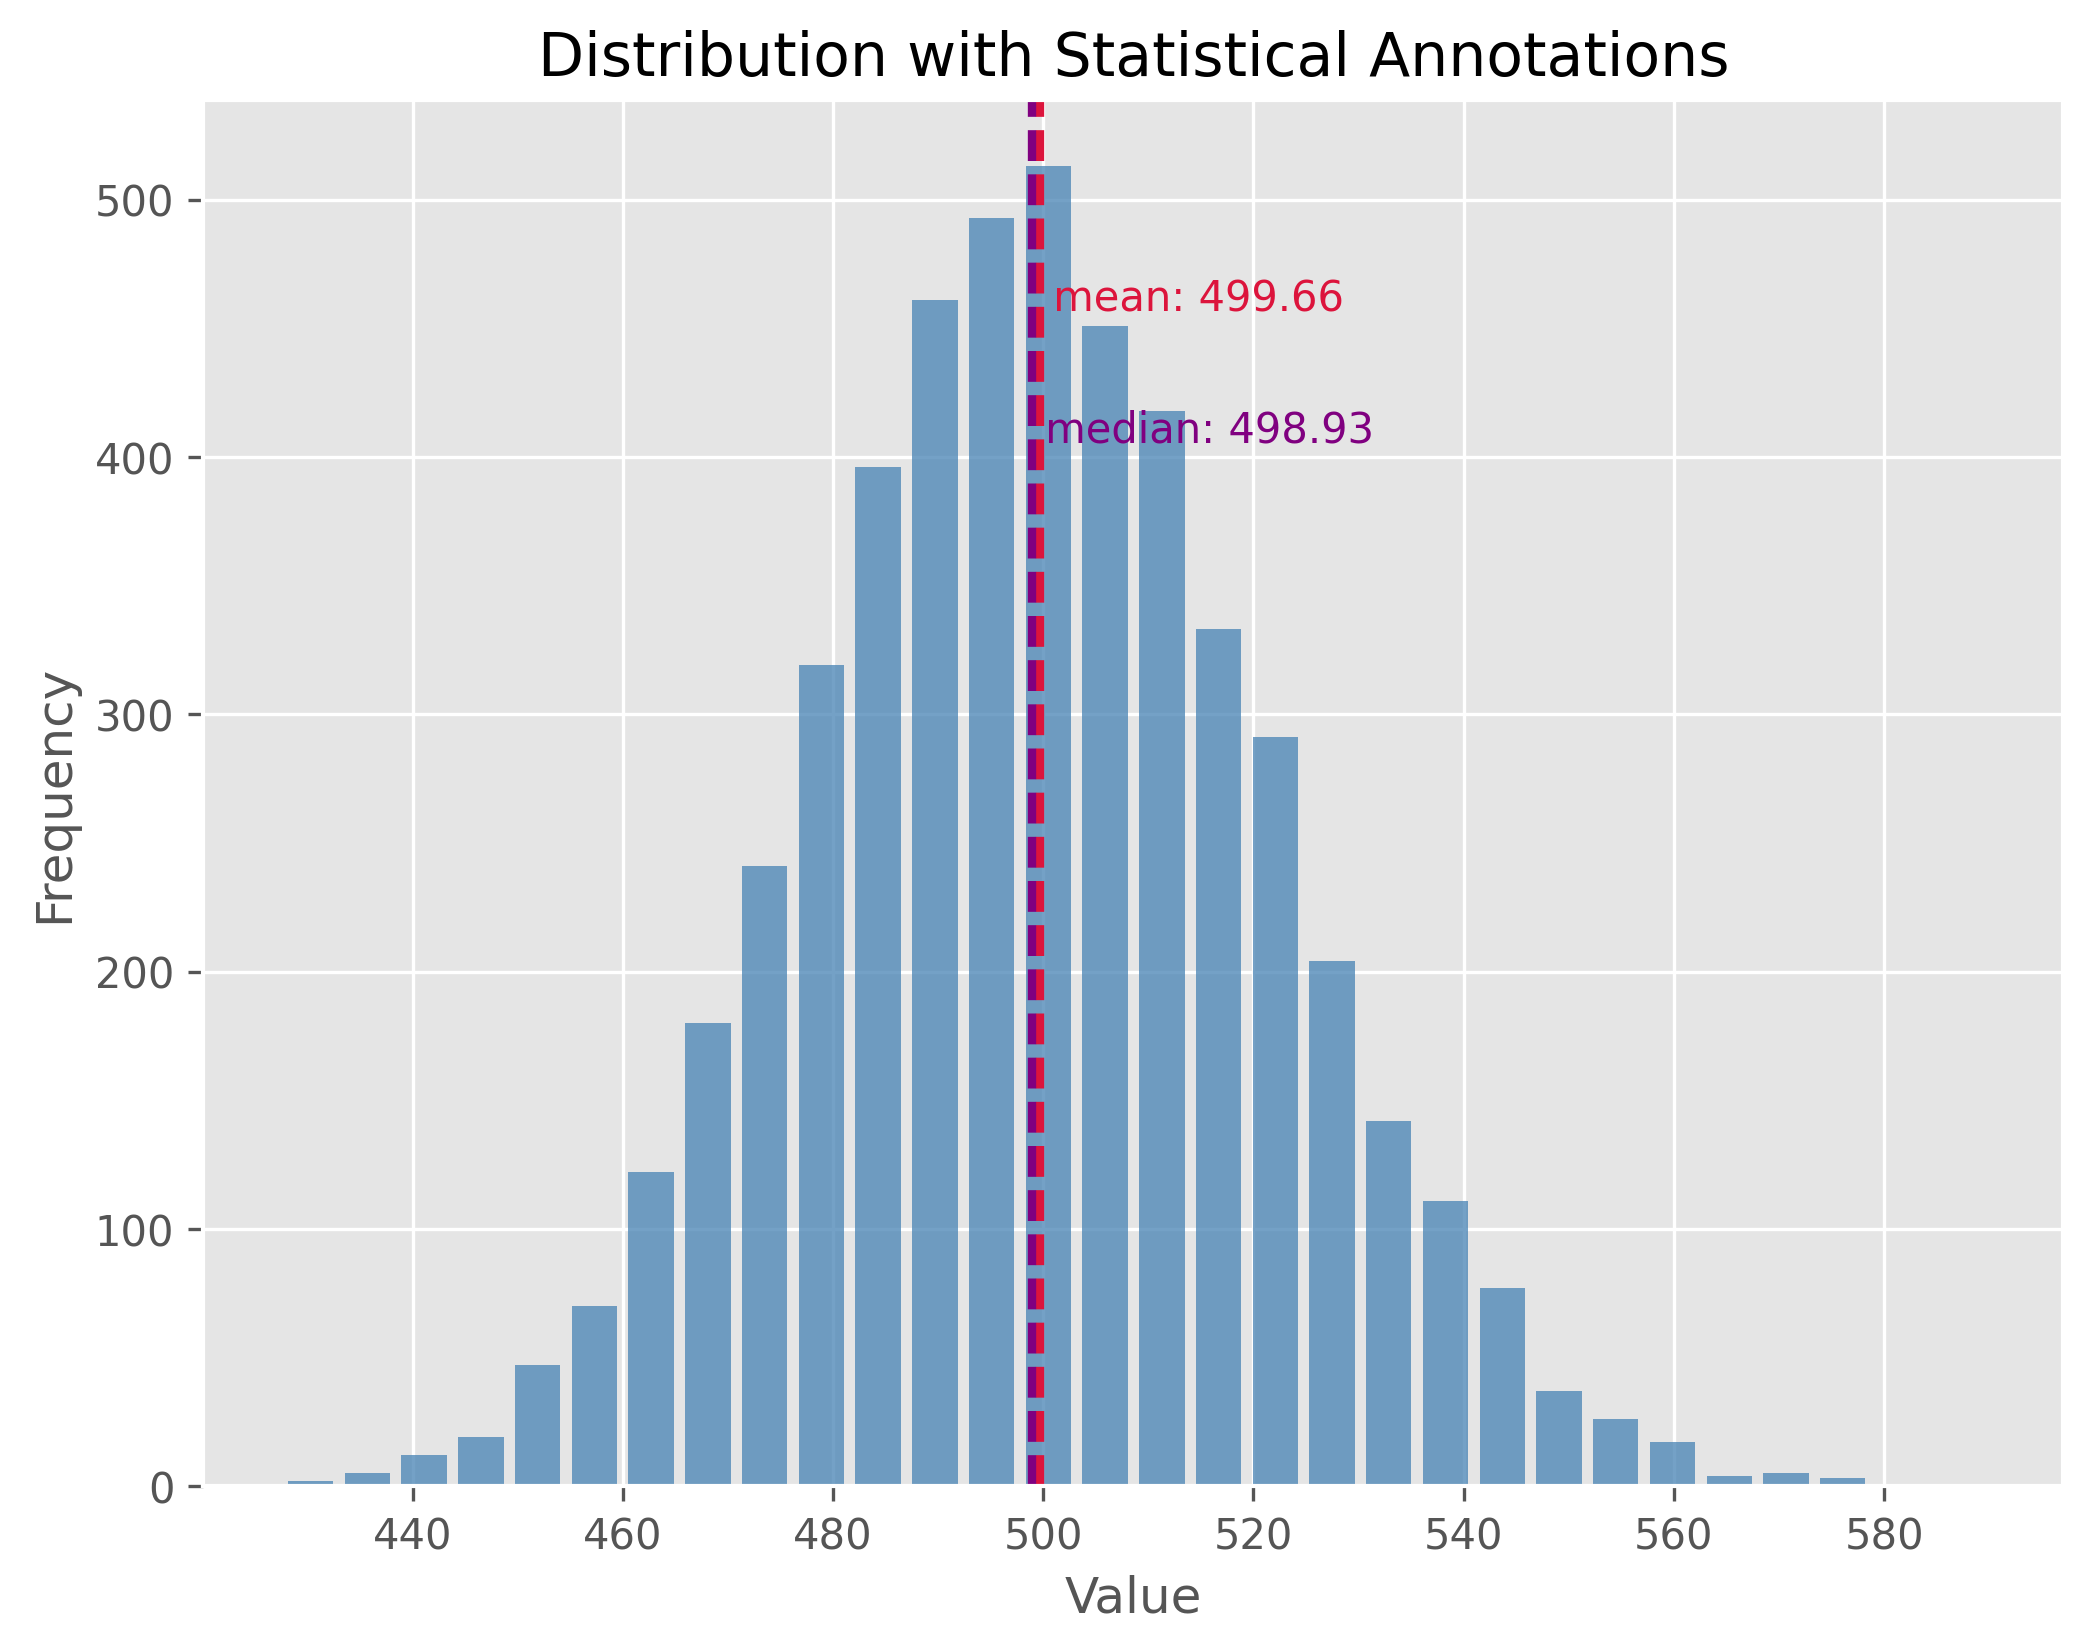

In [ ]:
# Symmetric Distributions

np.random.seed(0)
data = np.random.gamma(500, 1, 5000)
plot_dist(data, 30, ["mean", "median"])



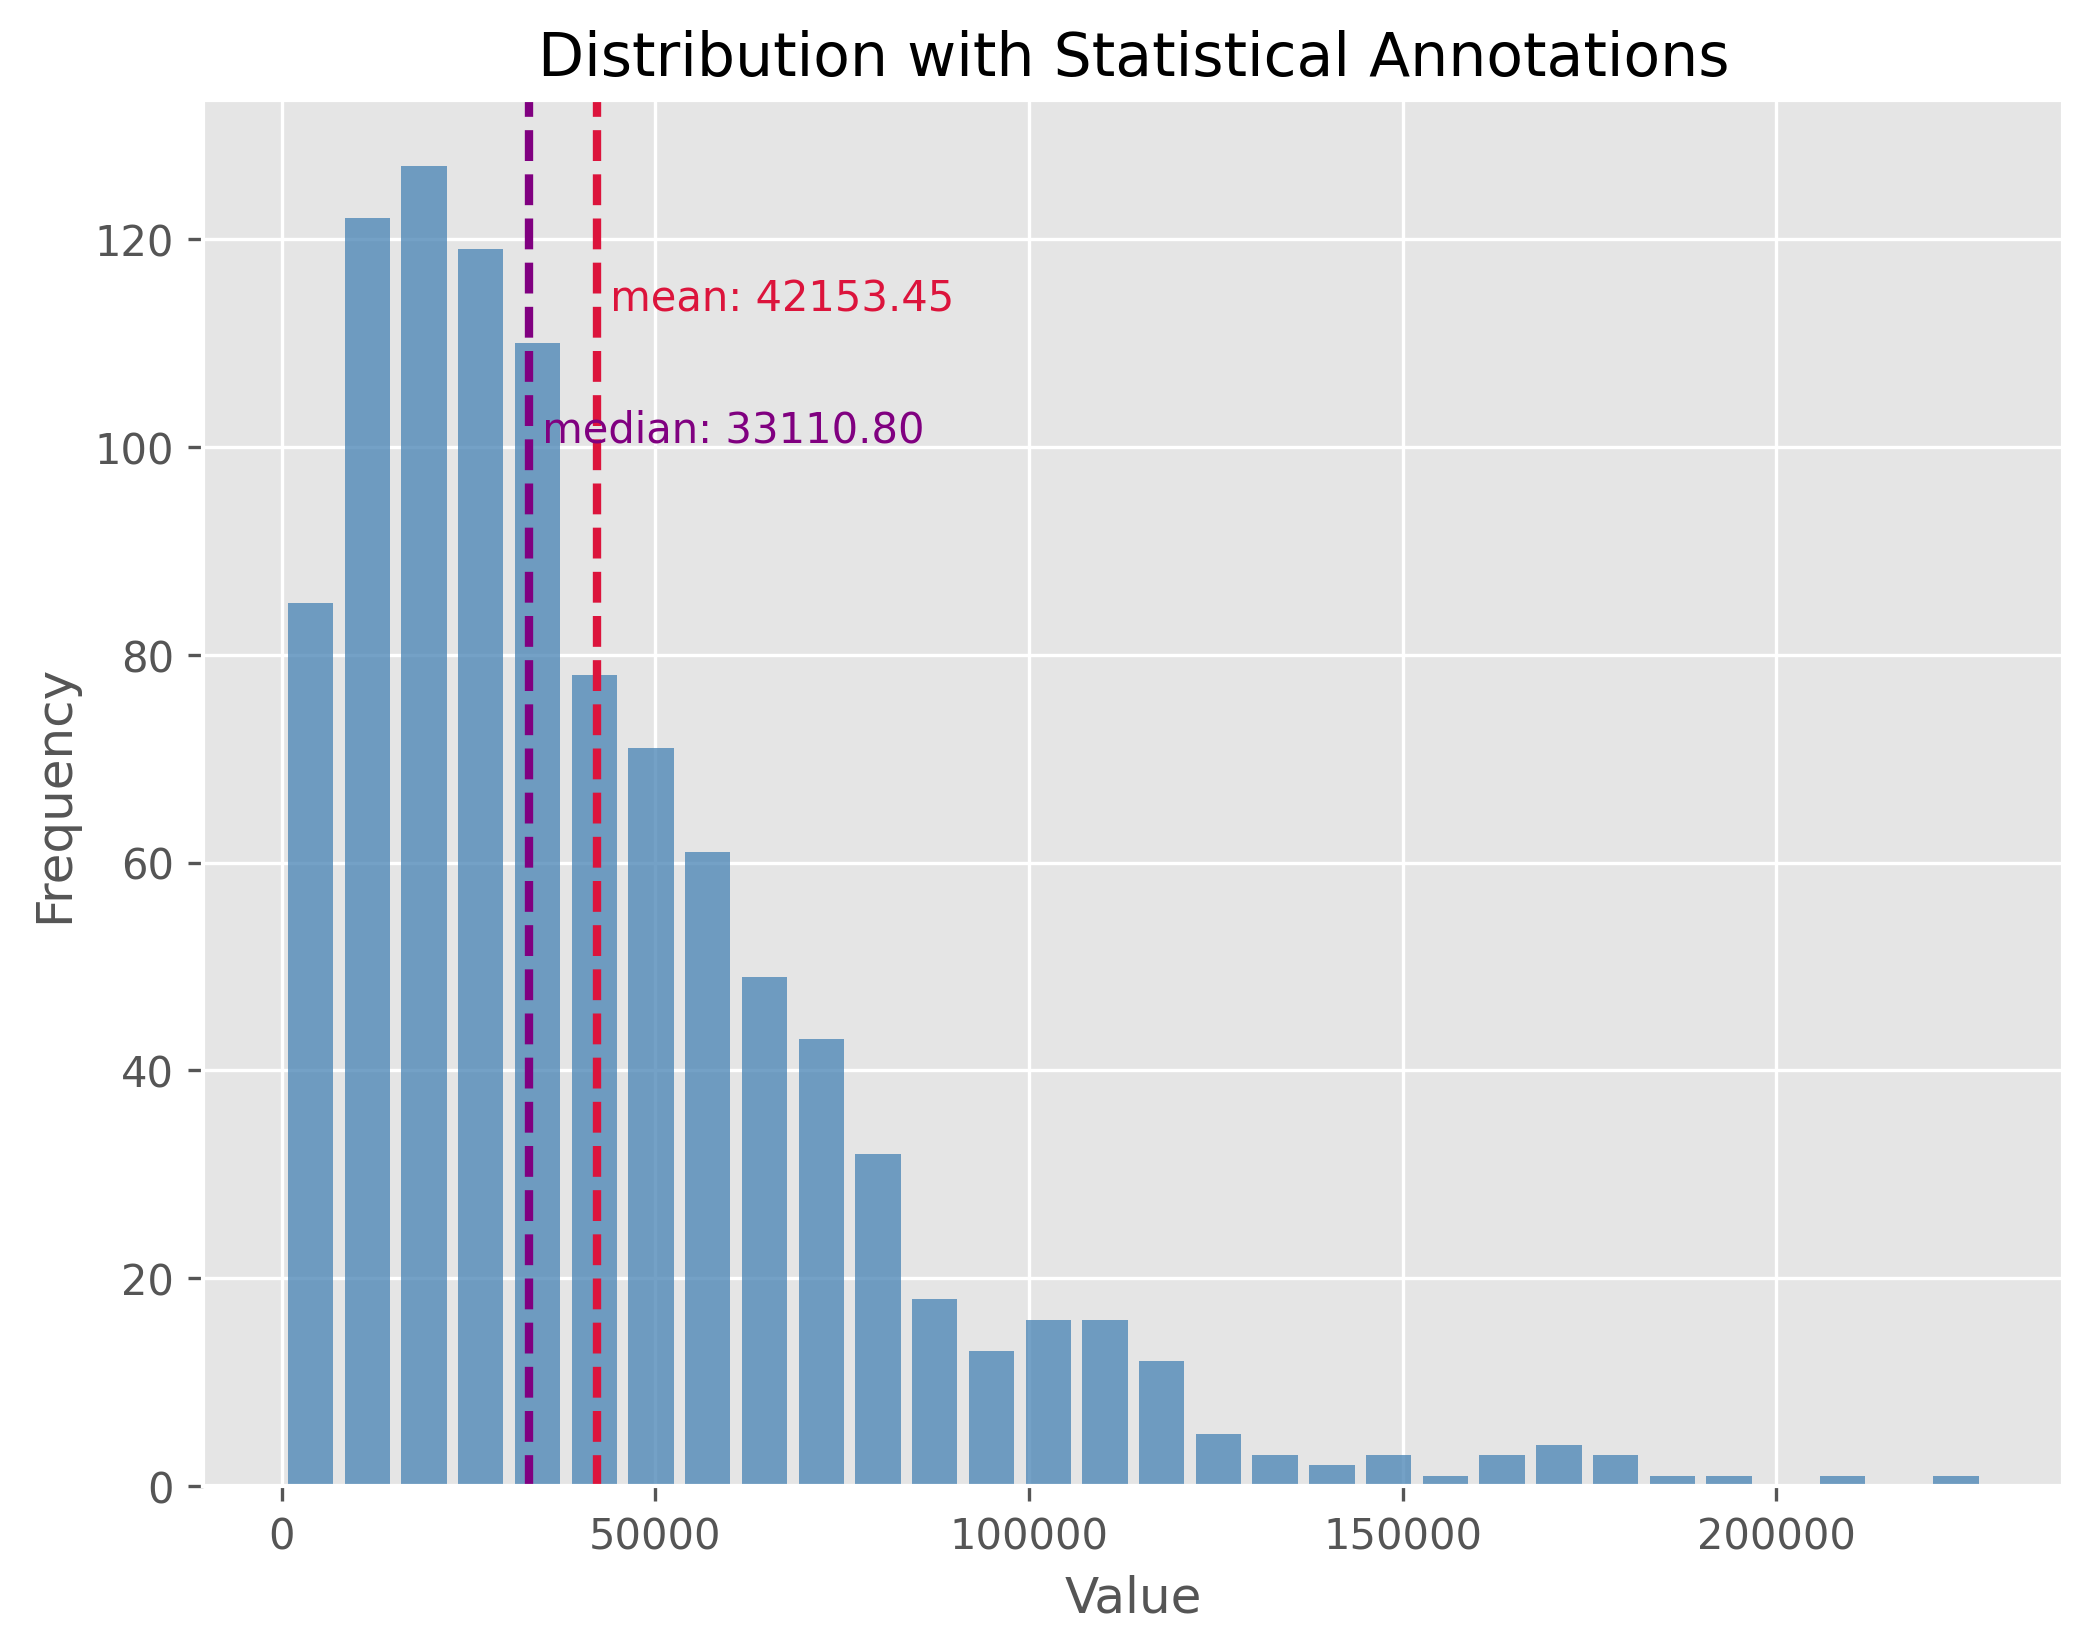

In [ ]:
# Non-Symmetric Distributions

data = np.random.gamma(1.6, 26000, 1000)
plot_dist(data, 30, ["mean", "median"])

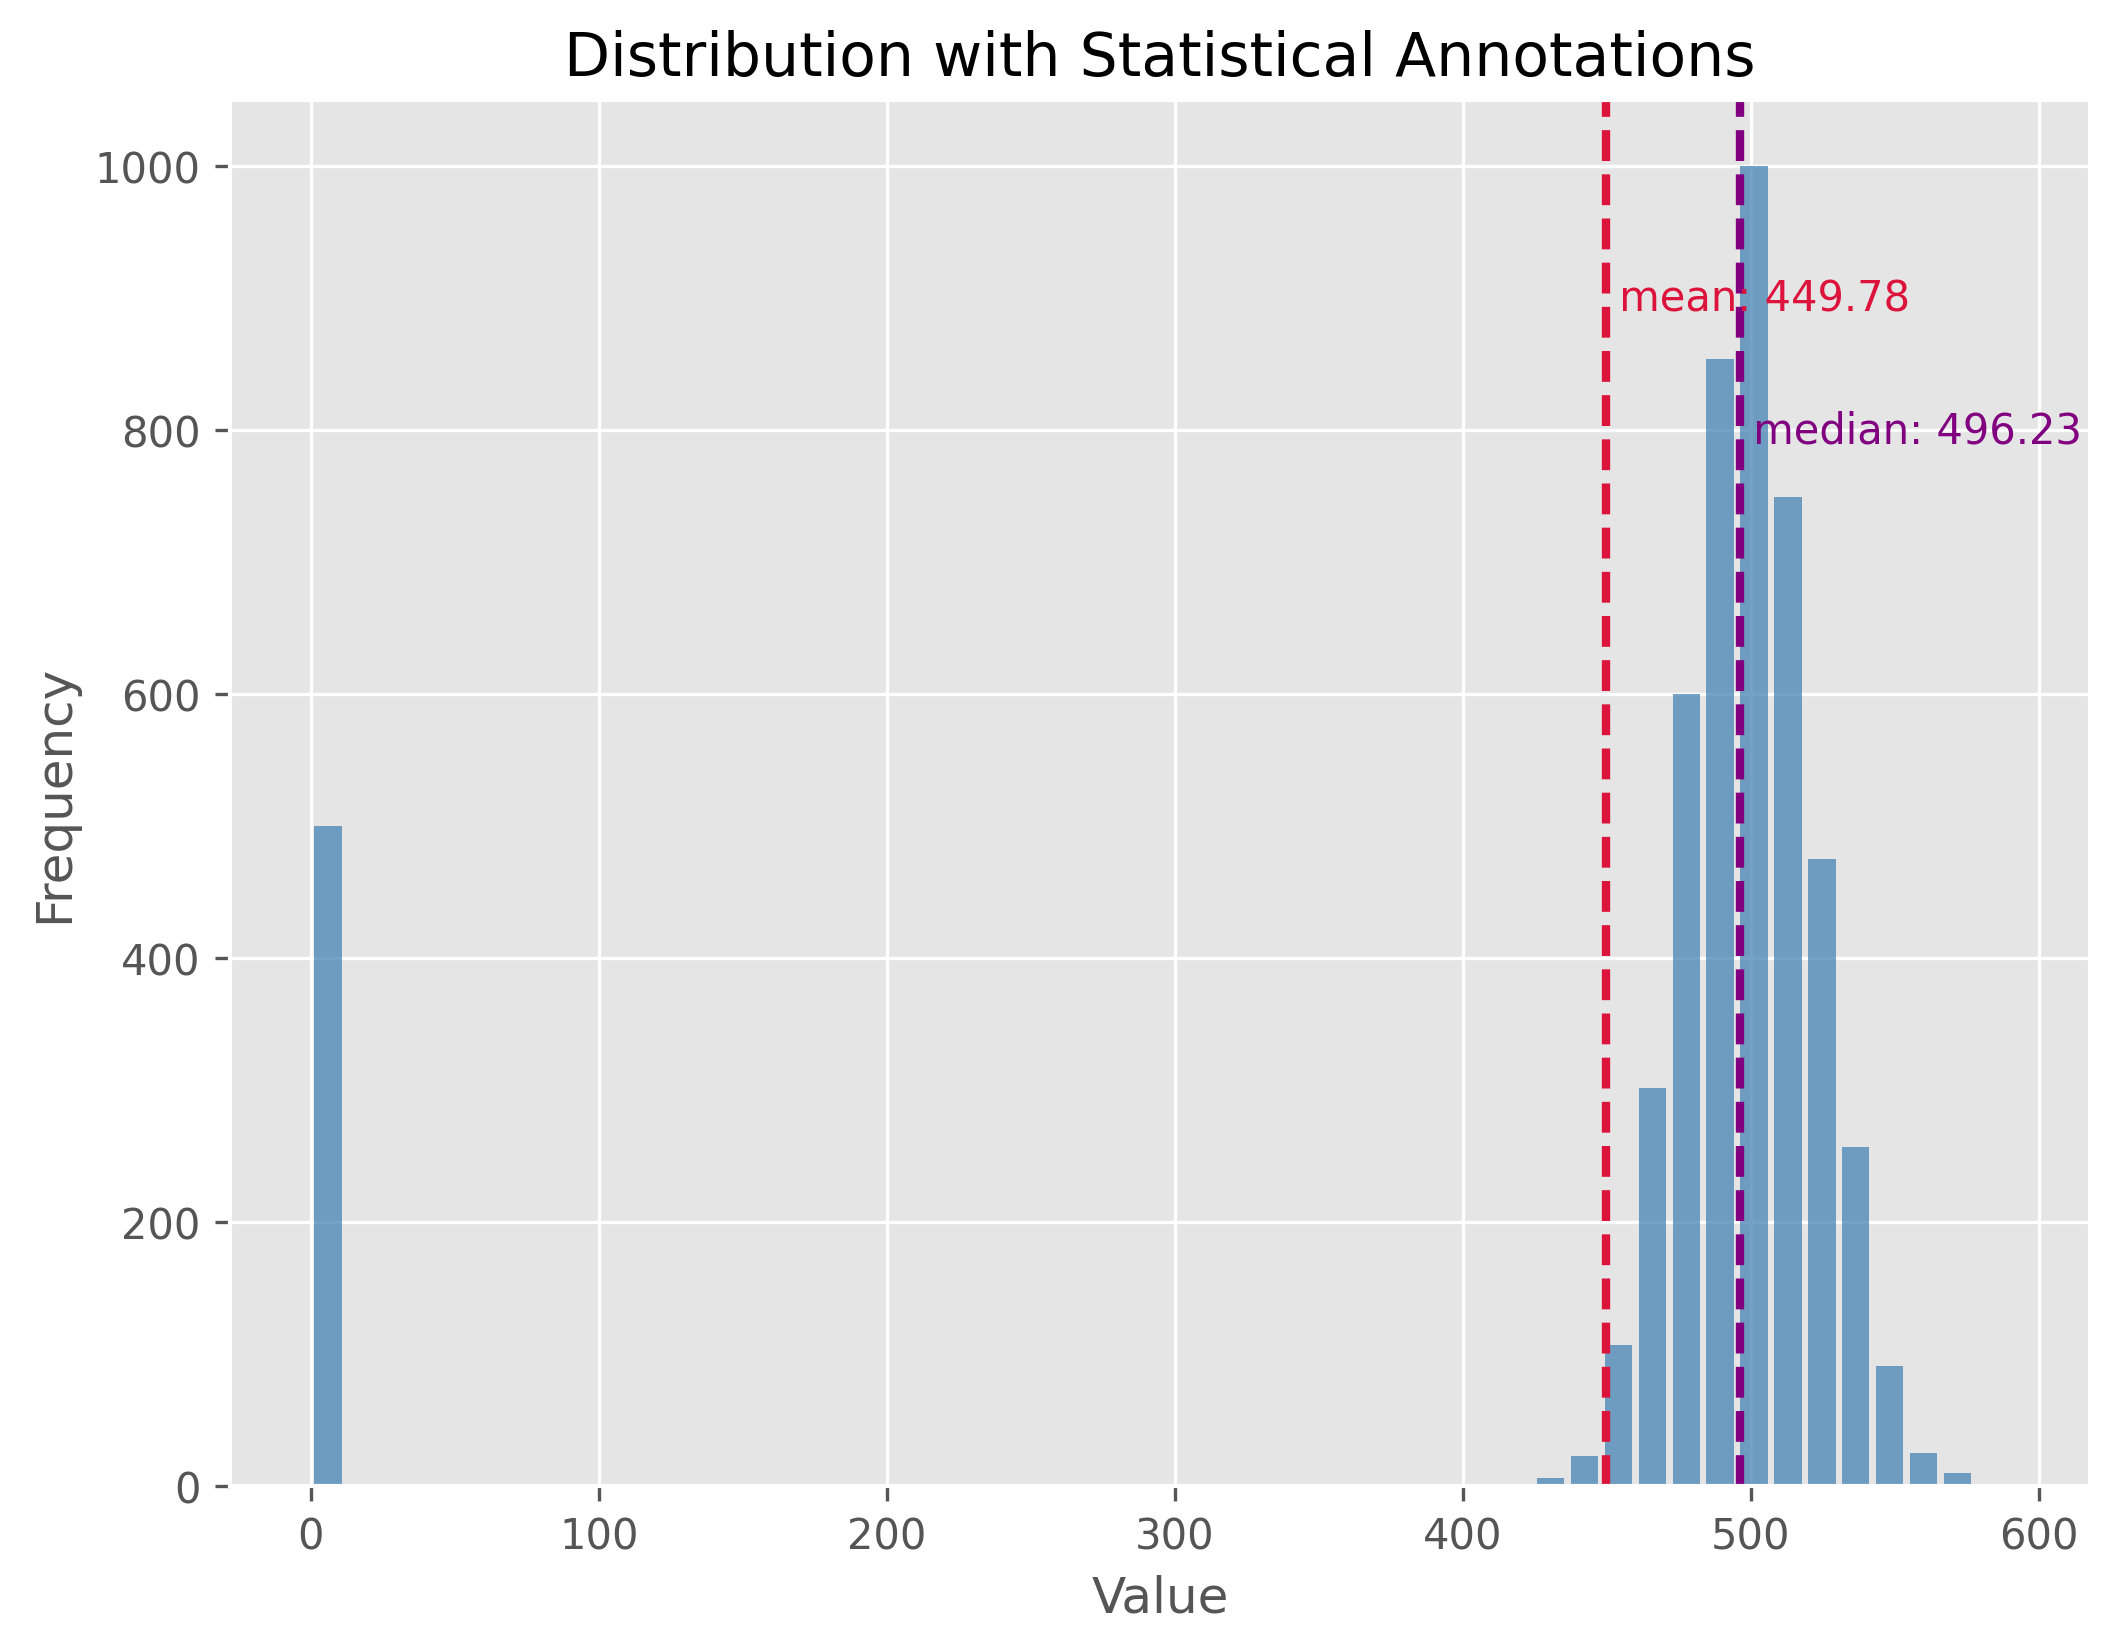

In [ ]:
# Distributions with Outliers

np.random.seed(0)
data = np.random.gamma(500, 1, 5000)
data[:500] = 0
plot_dist(data, 50, ["mean", "median"])

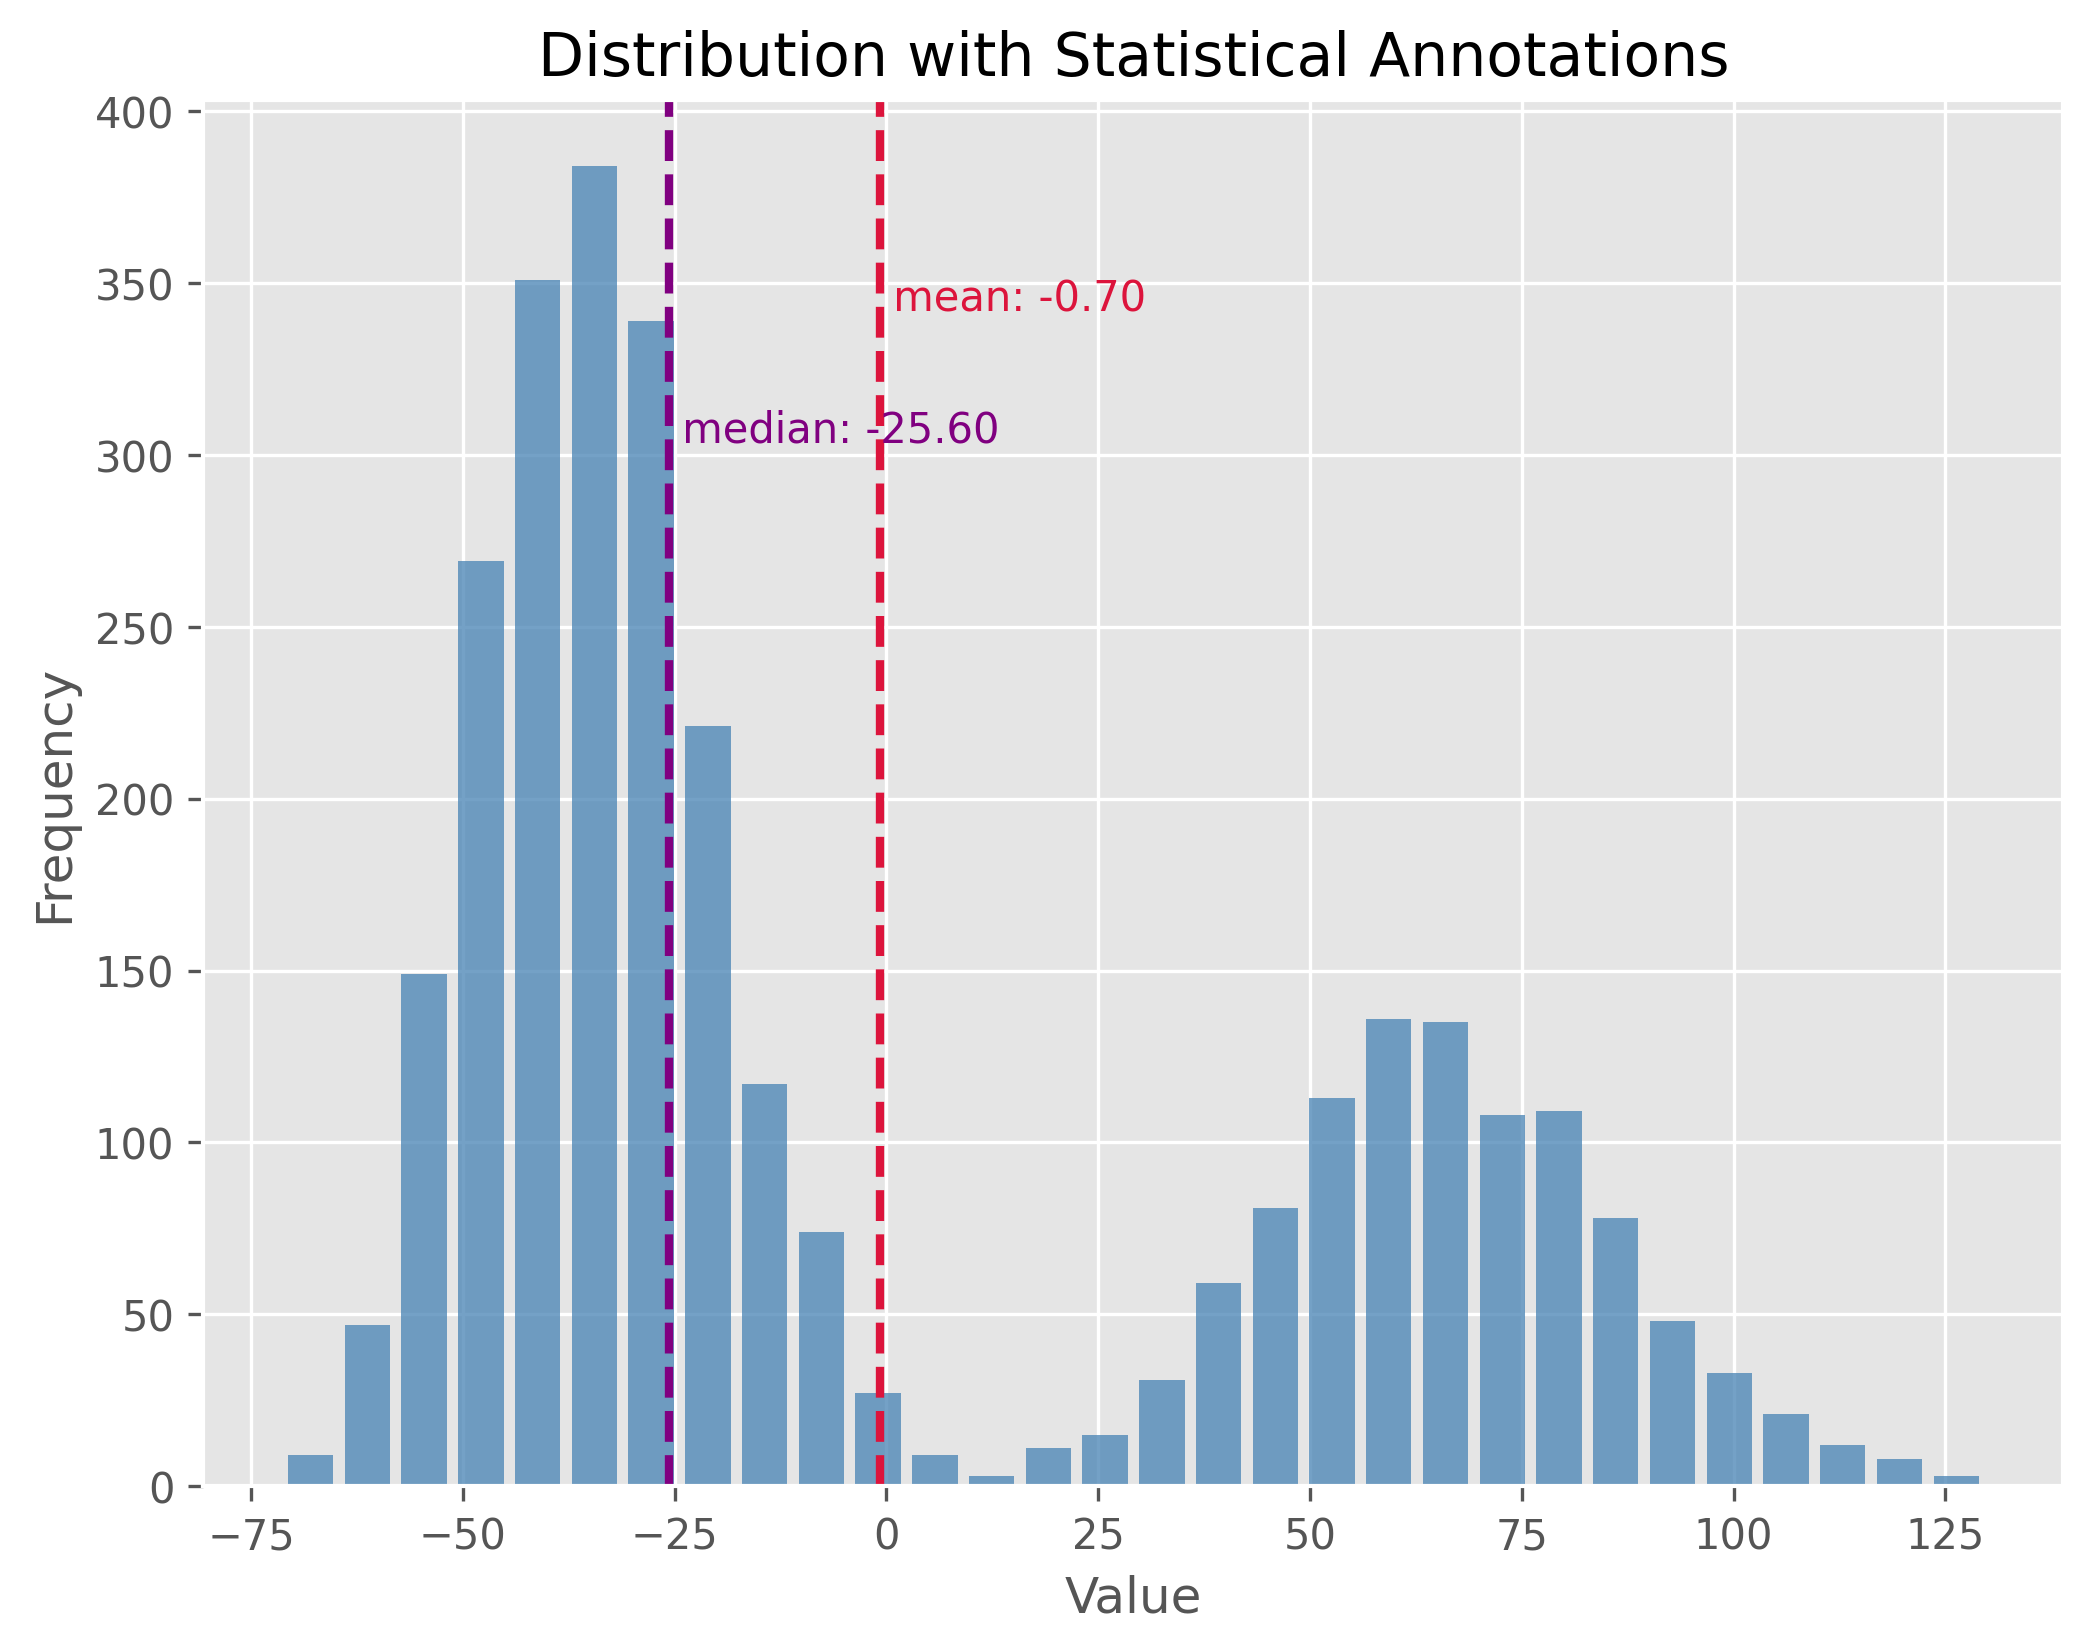

In [ ]:
# Multi-Modal Distributions

np.random.seed(0)
data1 = np.random.gamma(50, 2, 2000)
data2 = np.random.gamma(100, 2, 1000)
data = np.concatenate((data1, data2)) - 134

plot_dist(data, 30, ["mean", "median"])

In [ ]:
#Build up some (fake) data
#Using data from Florian-Huber

filename = r"https://raw.githubusercontent.com/florian-huber/data_science_course/a595bd6b19565cedff0c3917012be6e05223f7fb/datasets/datasaurus.csv"

# read data
data = pd.read_csv(filename)

# prepare data
new_names = "ABCDEFGHIJKLMNOP"
convert_names = {x: new_names[i] for i, x in enumerate(data["dataset"].unique())}

data["dataset"] = data["dataset"].apply(lambda x: convert_names[x])

datasets = []
for value in data["dataset"].unique():
    mask = data["dataset"] == value
    datasets.append(data[mask].drop(columns=["dataset"]))

print(data.head(3))

  dataset        x        y
0       A  55.3846  97.1795
1       A  51.5385  96.0256
2       A  46.1538  94.4872


In [ ]:
#Pandas groupby

#We can use Pandas and its groupby method to quickly get several important statistical measures on all 14 subsets.

cols = [("x", "count"), ("x", "mean"), ("x", "std"),
       ("y", "count"), ("y", "mean"), ("y", "std")]
print(data.groupby('dataset').describe()[cols])

# Describe what you see. Are these datasets distributed similarly?

             x                            y                      
         count       mean        std  count       mean        std
dataset                                                          
A        142.0  54.263273  16.765142  142.0  47.832253  26.935403
B        142.0  54.266100  16.769825  142.0  47.834721  26.939743
C        142.0  54.261442  16.765898  142.0  47.830252  26.939876
D        142.0  54.269927  16.769959  142.0  47.836988  26.937684
E        142.0  54.260150  16.769958  142.0  47.839717  26.930002
F        142.0  54.267341  16.768959  142.0  47.839545  26.930275
G        142.0  54.268805  16.766704  142.0  47.835450  26.939998
H        142.0  54.260303  16.767735  142.0  47.839829  26.930192
I        142.0  54.267320  16.760013  142.0  47.837717  26.930036
J        142.0  54.268730  16.769239  142.0  47.830823  26.935727
K        142.0  54.265882  16.768853  142.0  47.831496  26.938608
L        142.0  54.267849  16.766759  142.0  47.835896  26.936105
M        1

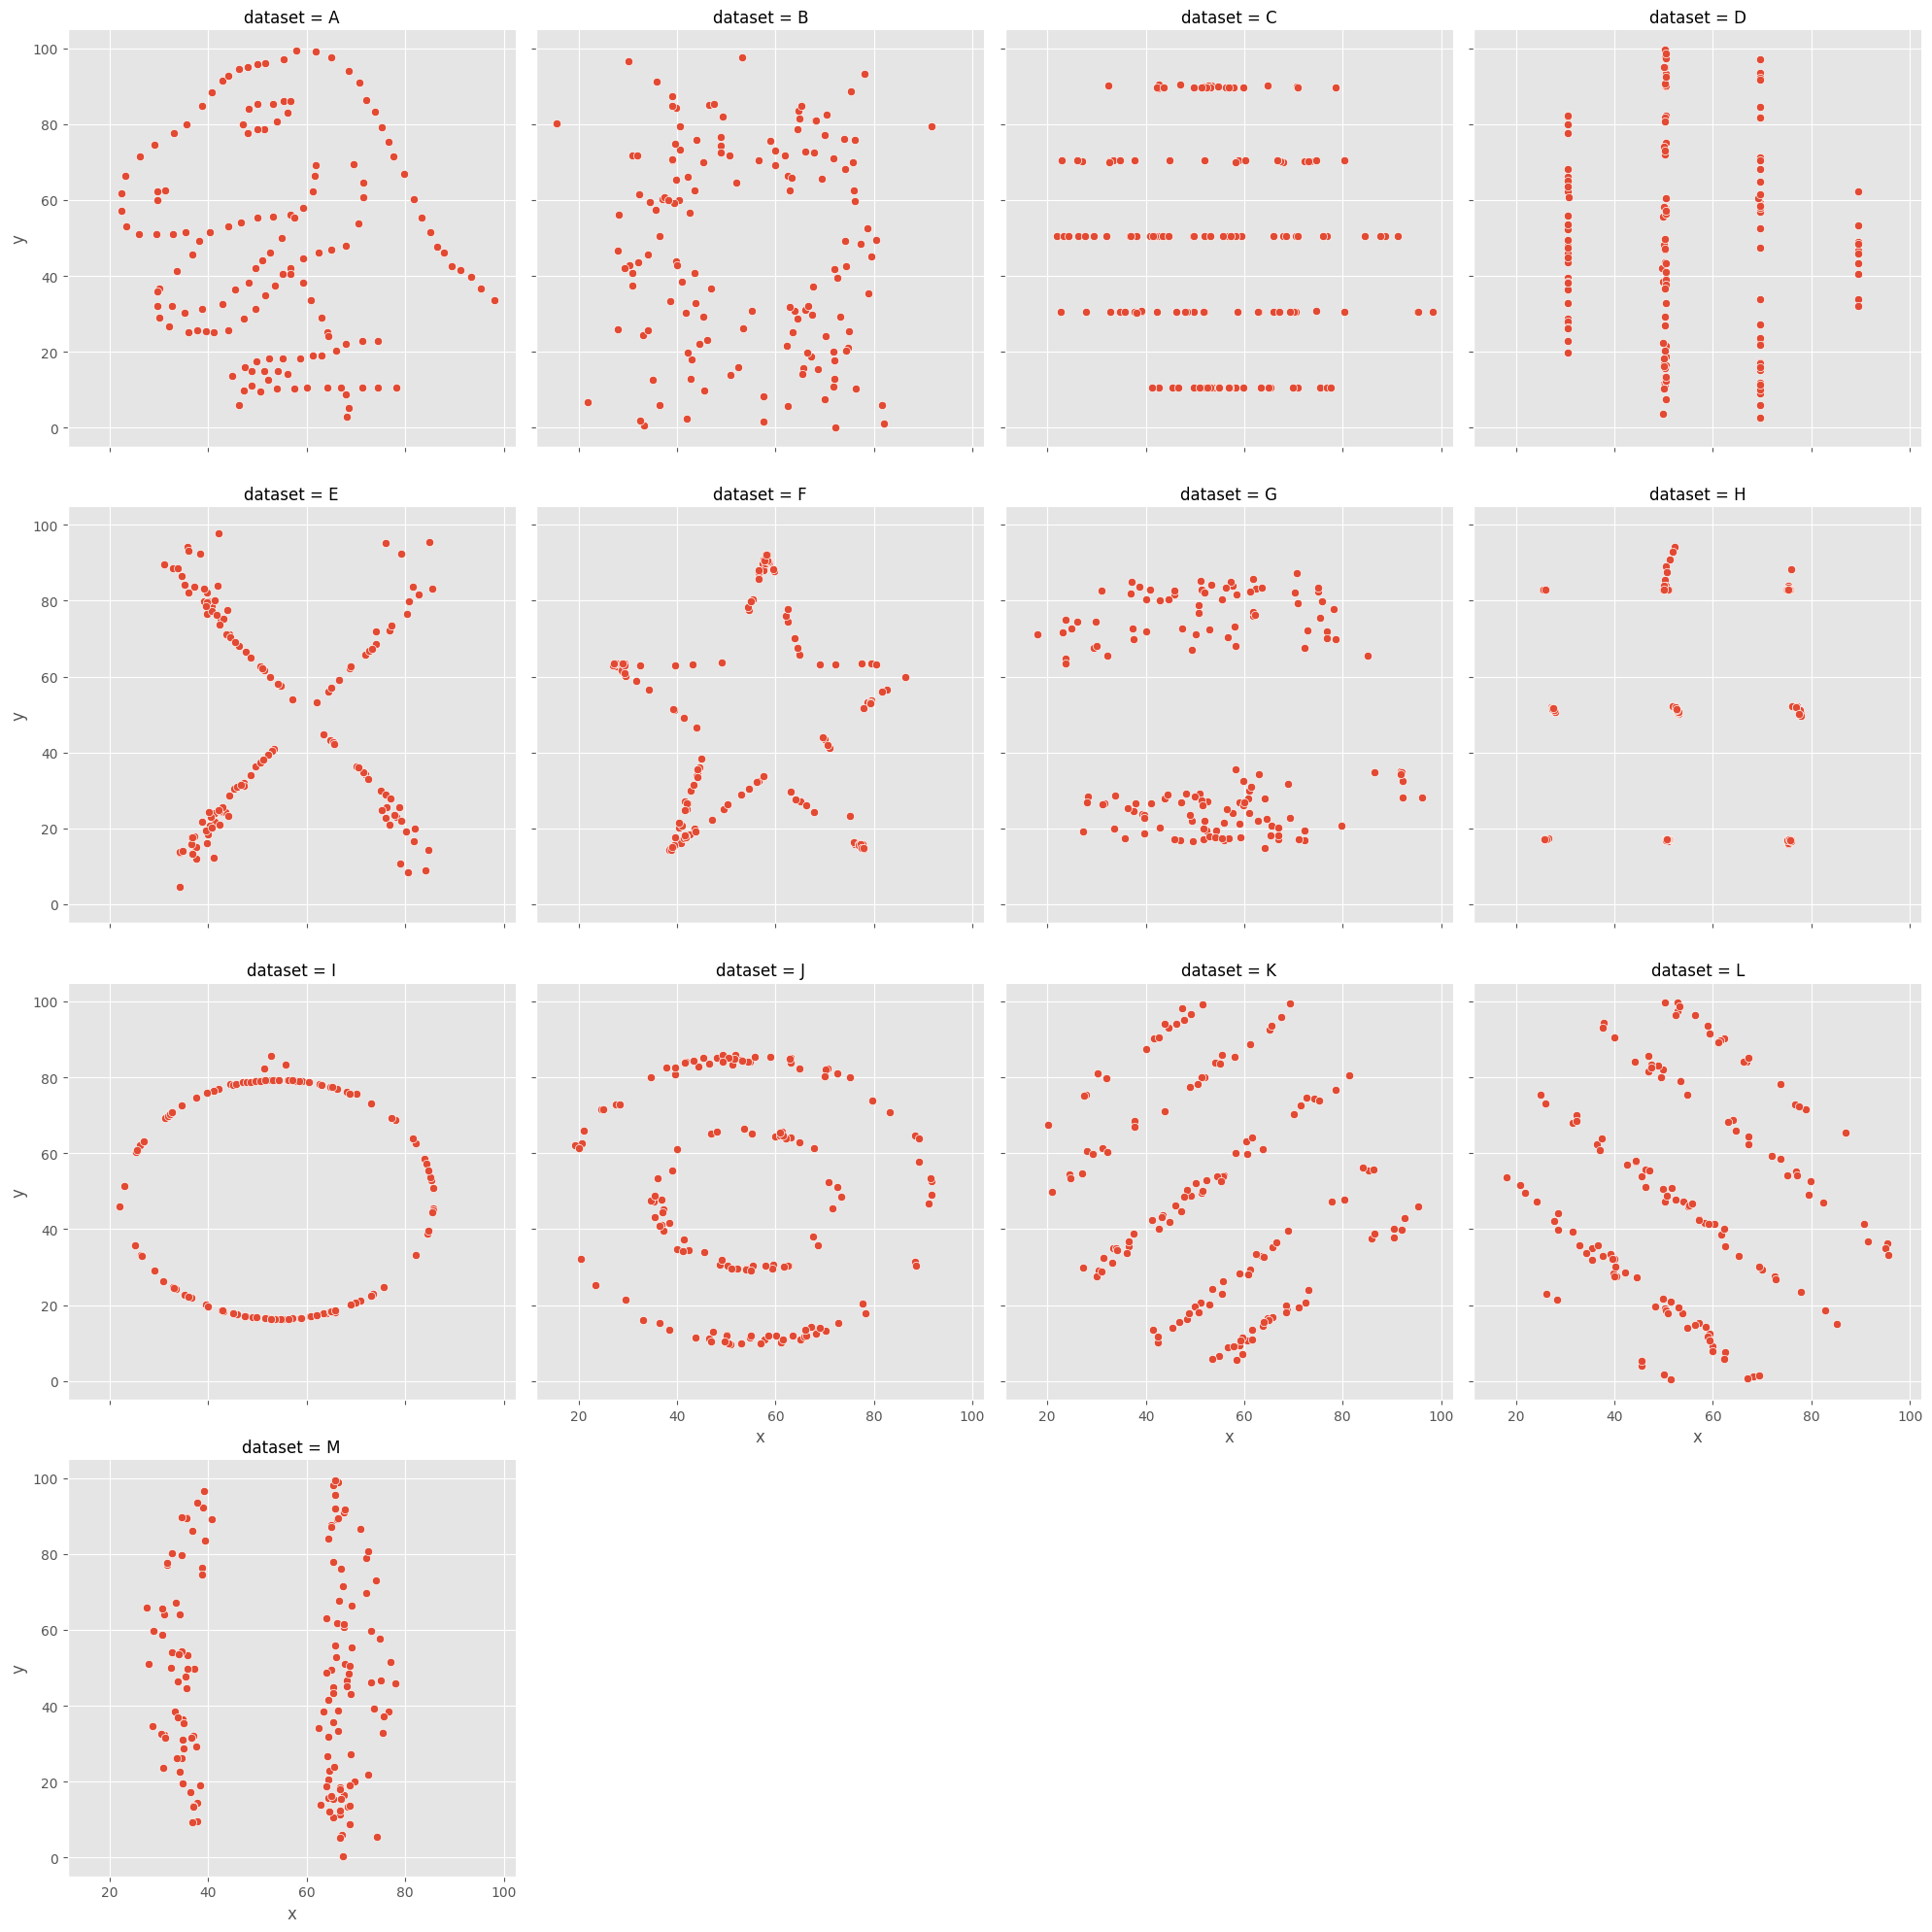

In [ ]:
import seaborn as sb
sb.relplot(x="x", y="y", col="dataset", kind="scatter", data=data, col_wrap=4)


## Basic Statistical Plots

1. **Box Plot:** provides a visual summary of the minimum, first quartile, median, third quartile, and maximum of a dataset.
  - Pros:
    - Efficiently represents the data's spread and central tendency.
    - Useful for identifying outliers and comparing distributions across groups
  - Cons:
    - Can be challenging to interpret for those unfamiliar with the plot's elements.
    - It doesn't represent the nuances in distributions
2. Strip Plot: A scatter plot where one axis is categorical.
  - Pros:
    - It offers a sense of the density and distribution of data points.
    - Clearly shows individual data points.
  - Cons:
    - Can become cluttered and less interpretable with large datasets as points overlap.
    - Doesn't provide summary statistics about the data.
3. Swarm Plot: Similar to a strip plot where data points are adjusted (or "swarmed") to avoid overlap, giving a clearer representation of the distribution of values.
  - Pros:
    - It offers a clearer view of the distribution than strip plots for moderate datasets.
    - Good for visualizing the density of the data.
  - Cons:
    - Not suitable for very large datasets as it can become cluttered and slow to render.- Like the strip plot, it lacks summary statistics.
4. Violin Plot: Combines the benefits of both box plots and kernel density plots.
  - Pros:
    - It offers a detailed view of the data's distribution, including its density.
    - Combines the best of box plots (summary statistics) and density plots (distribution shape).
  - Cons:
    - Requires a degree of smoothing, which can be perceived as manipulating or altering the true nature of the data.
    - Can be harder for newcomers to interpret compared to simpler plots.


Text(0.5, 0.98, 'Different ways to include distribution properties')

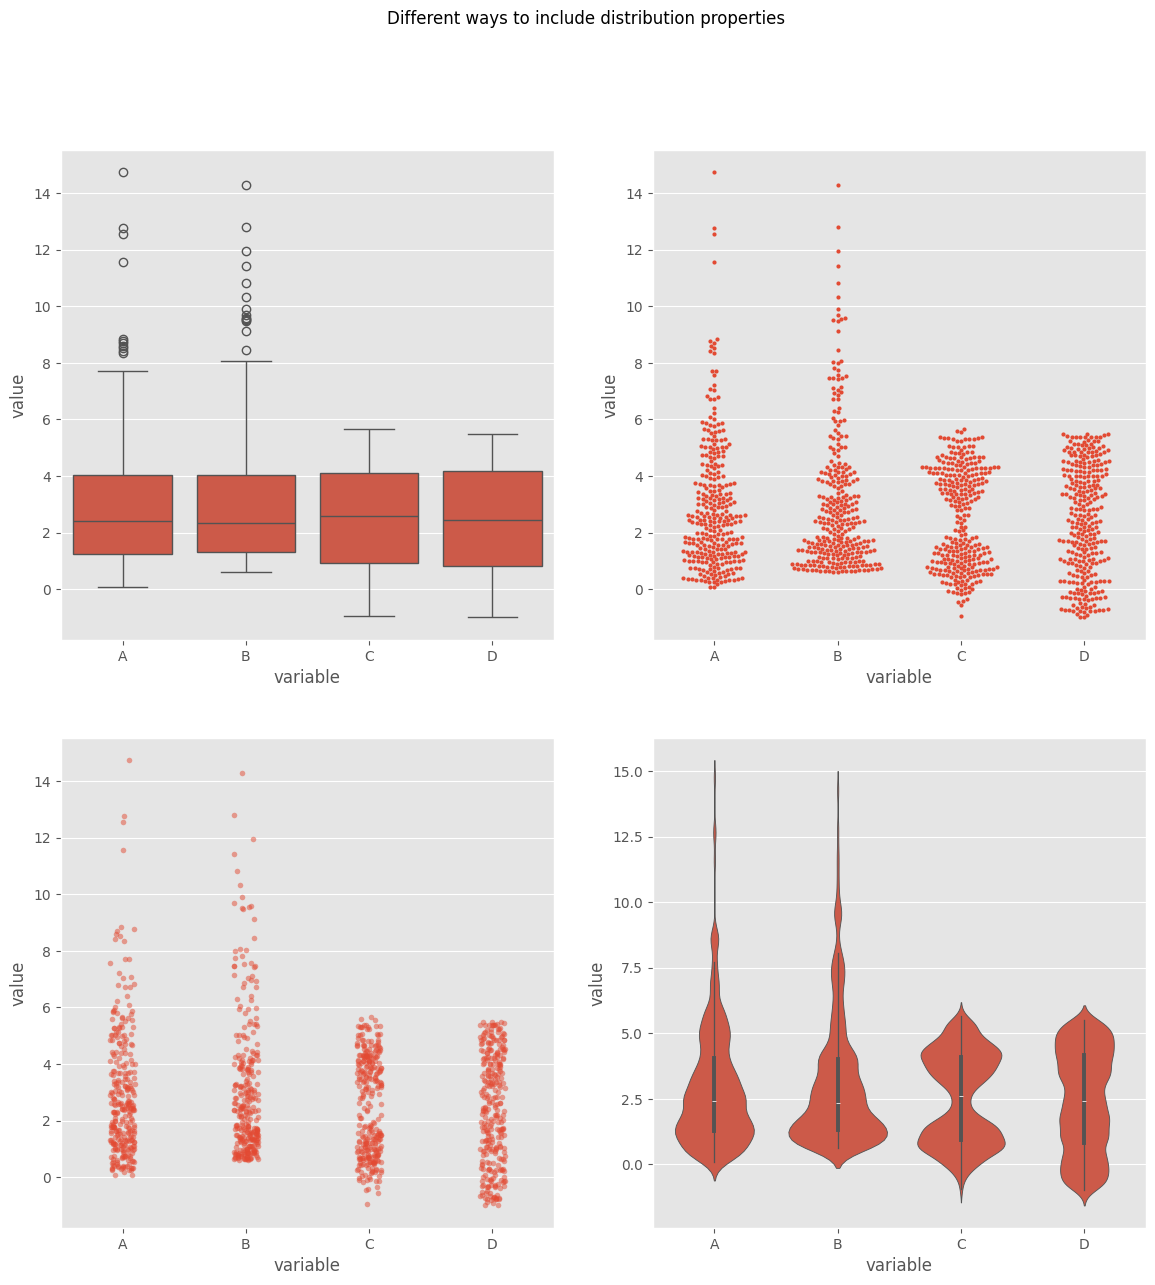

In [ ]:
# create toy data
from matplotlib import pyplot as plt
import seaborn as sb

np.random.seed(0)

data1 = np.random.normal(4, 0.7, 150)
data2 = np.random.normal(1, 0.7, 150)
dataC = np.concatenate((data1, data2))

datasets_test = pd.DataFrame({"A": np.random.gamma(1.6, 2, 300),
                             "B": 0.6 + np.random.exponential(2.2, 300),
                             "C": dataC,
                             "D": np.random.uniform(-1, 5.5, 300)})
fig, ax = plt.subplots(2, 2, figsize=(14, 14))

sb.boxplot(x="variable", y="value", data=pd.melt(datasets_test),
          ax=ax[0][0])

sb.stripplot(x="variable", y="value", data=pd.melt(datasets_test),
          ax=ax[1][0], alpha=0.5, size=4)

sb.swarmplot(x="variable", y="value", data=pd.melt(datasets_test),
          ax=ax[0][1], size=3)

sb.violinplot(x="variable", y="value", data=pd.melt(datasets_test),
          ax=ax[1][1], bw_method=0.15)  # bw for "bandwidth" controls the degree of smoothing

fig.suptitle("Different ways to include distribution properties")

## Example - Income and Wealth

Let's dive into a fictional, but realistic, data. This data is generated based on an actual distribution from Germany in 2024 (see [Link to Statistisches Bundesamt](https://www.destatis.de/DE/Presse/Pressemitteilungen/2025/04/PD25_134_621.html)).

This data shows us the distribution of monthly gross incomes in full time equivalents (that means the income from a 50% job is scaled to a virtual 100% employment). The data was based on information received by about 5,000 randomly selected, voluntary participants.

For raw data requests, you can visit [this site](https://paneldata.org/).



In [ ]:
# Generate some representative data
from scipy.stats import invgamma
from scipy.optimize import curve_fit


# Recent income data from Germany (2024) - taken from https://www.destatis.de/DE/Presse/Pressemitteilungen/2025/04/PD25_134_621.html
income_percentiles = pd.DataFrame({
    "percentile": [99, 90, 80, 70, 60, 50, 40, 30, 20, 10],
    "income": [213_286, 97_680, 77_105, 65_843, 58_214, 52_159, 47_244, 42_700, 37_944, 32_526]
})


# Functions to generate fake data following the actual distribution (to produce fake but realistic data)
def fit_invgamma(data_percentiles):
    """
    Fit an inverse gamma distribution to the given income percentiles.

    Parameters:
        data_percentiles (pd.DataFrame): DataFrame with columns:
            - 'percentile': Percentile values (e.g., 10, 20, ..., 99)
            - 'income': Income value corresponding to each percentile.
    """
    # Sort the DataFrame in ascending order by percentile.
    df_sorted = data_percentiles.sort_values("percentile")

    # Convert percentiles into probabilities (e.g., 10 becomes 0.10).
    probabilities = df_sorted["percentile"].values / 100.0
    incomes = df_sorted["income"].values

    # Define the model function: the inverse gamma quantile (ppf) at probability 'p'.
    def invgamma_ppf(p, a, scale):
        return invgamma.ppf(p, a, scale=scale)

    # Provide an initial guess for [shape, scale].
    initial_guess = [2.0, 50000]

    # Fit the inverse gamma quantile function to the provided data.
    # We constrain the parameters to be positive.
    params, _ = curve_fit(invgamma_ppf, probabilities, incomes, p0=initial_guess,
                          bounds=([1e-6, 1e-6], [np.inf, np.inf]))

    fitted_shape, fitted_scale = params
    return fitted_shape, fitted_scale

def generate_synthetic_income_data_invgamma(data_percentiles, total_entries=30000):
    """
    Fit an inverse gamma distribution to the provided income percentiles
    and generate synthetic income data based on the fitted distribution.

    Parameters:
        data_percentiles (pd.DataFrame): DataFrame containing two columns:
            'percentile': e.g., 10, 20, …, 99
            'income': Corresponding income values
        total_entries (int): The number of synthetic income data points to generate.
    """
    # Fit the parameters (shape and scale) of the inverse gamma.
    fitted_shape, fitted_scale = fit_invgamma(data_percentiles)

    # Generate synthetic income data by sampling from the fitted inverse gamma distribution.
    synthetic_incomes = invgamma.rvs(fitted_shape, scale=fitted_scale, size=total_entries)

    return synthetic_incomes, (fitted_shape, fitted_scale)

# Code to generate a simulated income distribution for Germany (2024)
np.random.seed(0)
synthetic_incomes, parameters = generate_synthetic_income_data_invgamma(income_percentiles)
income_simulated = pd.DataFrame(synthetic_incomes / 12, columns=["income"])  # Set to monthly income

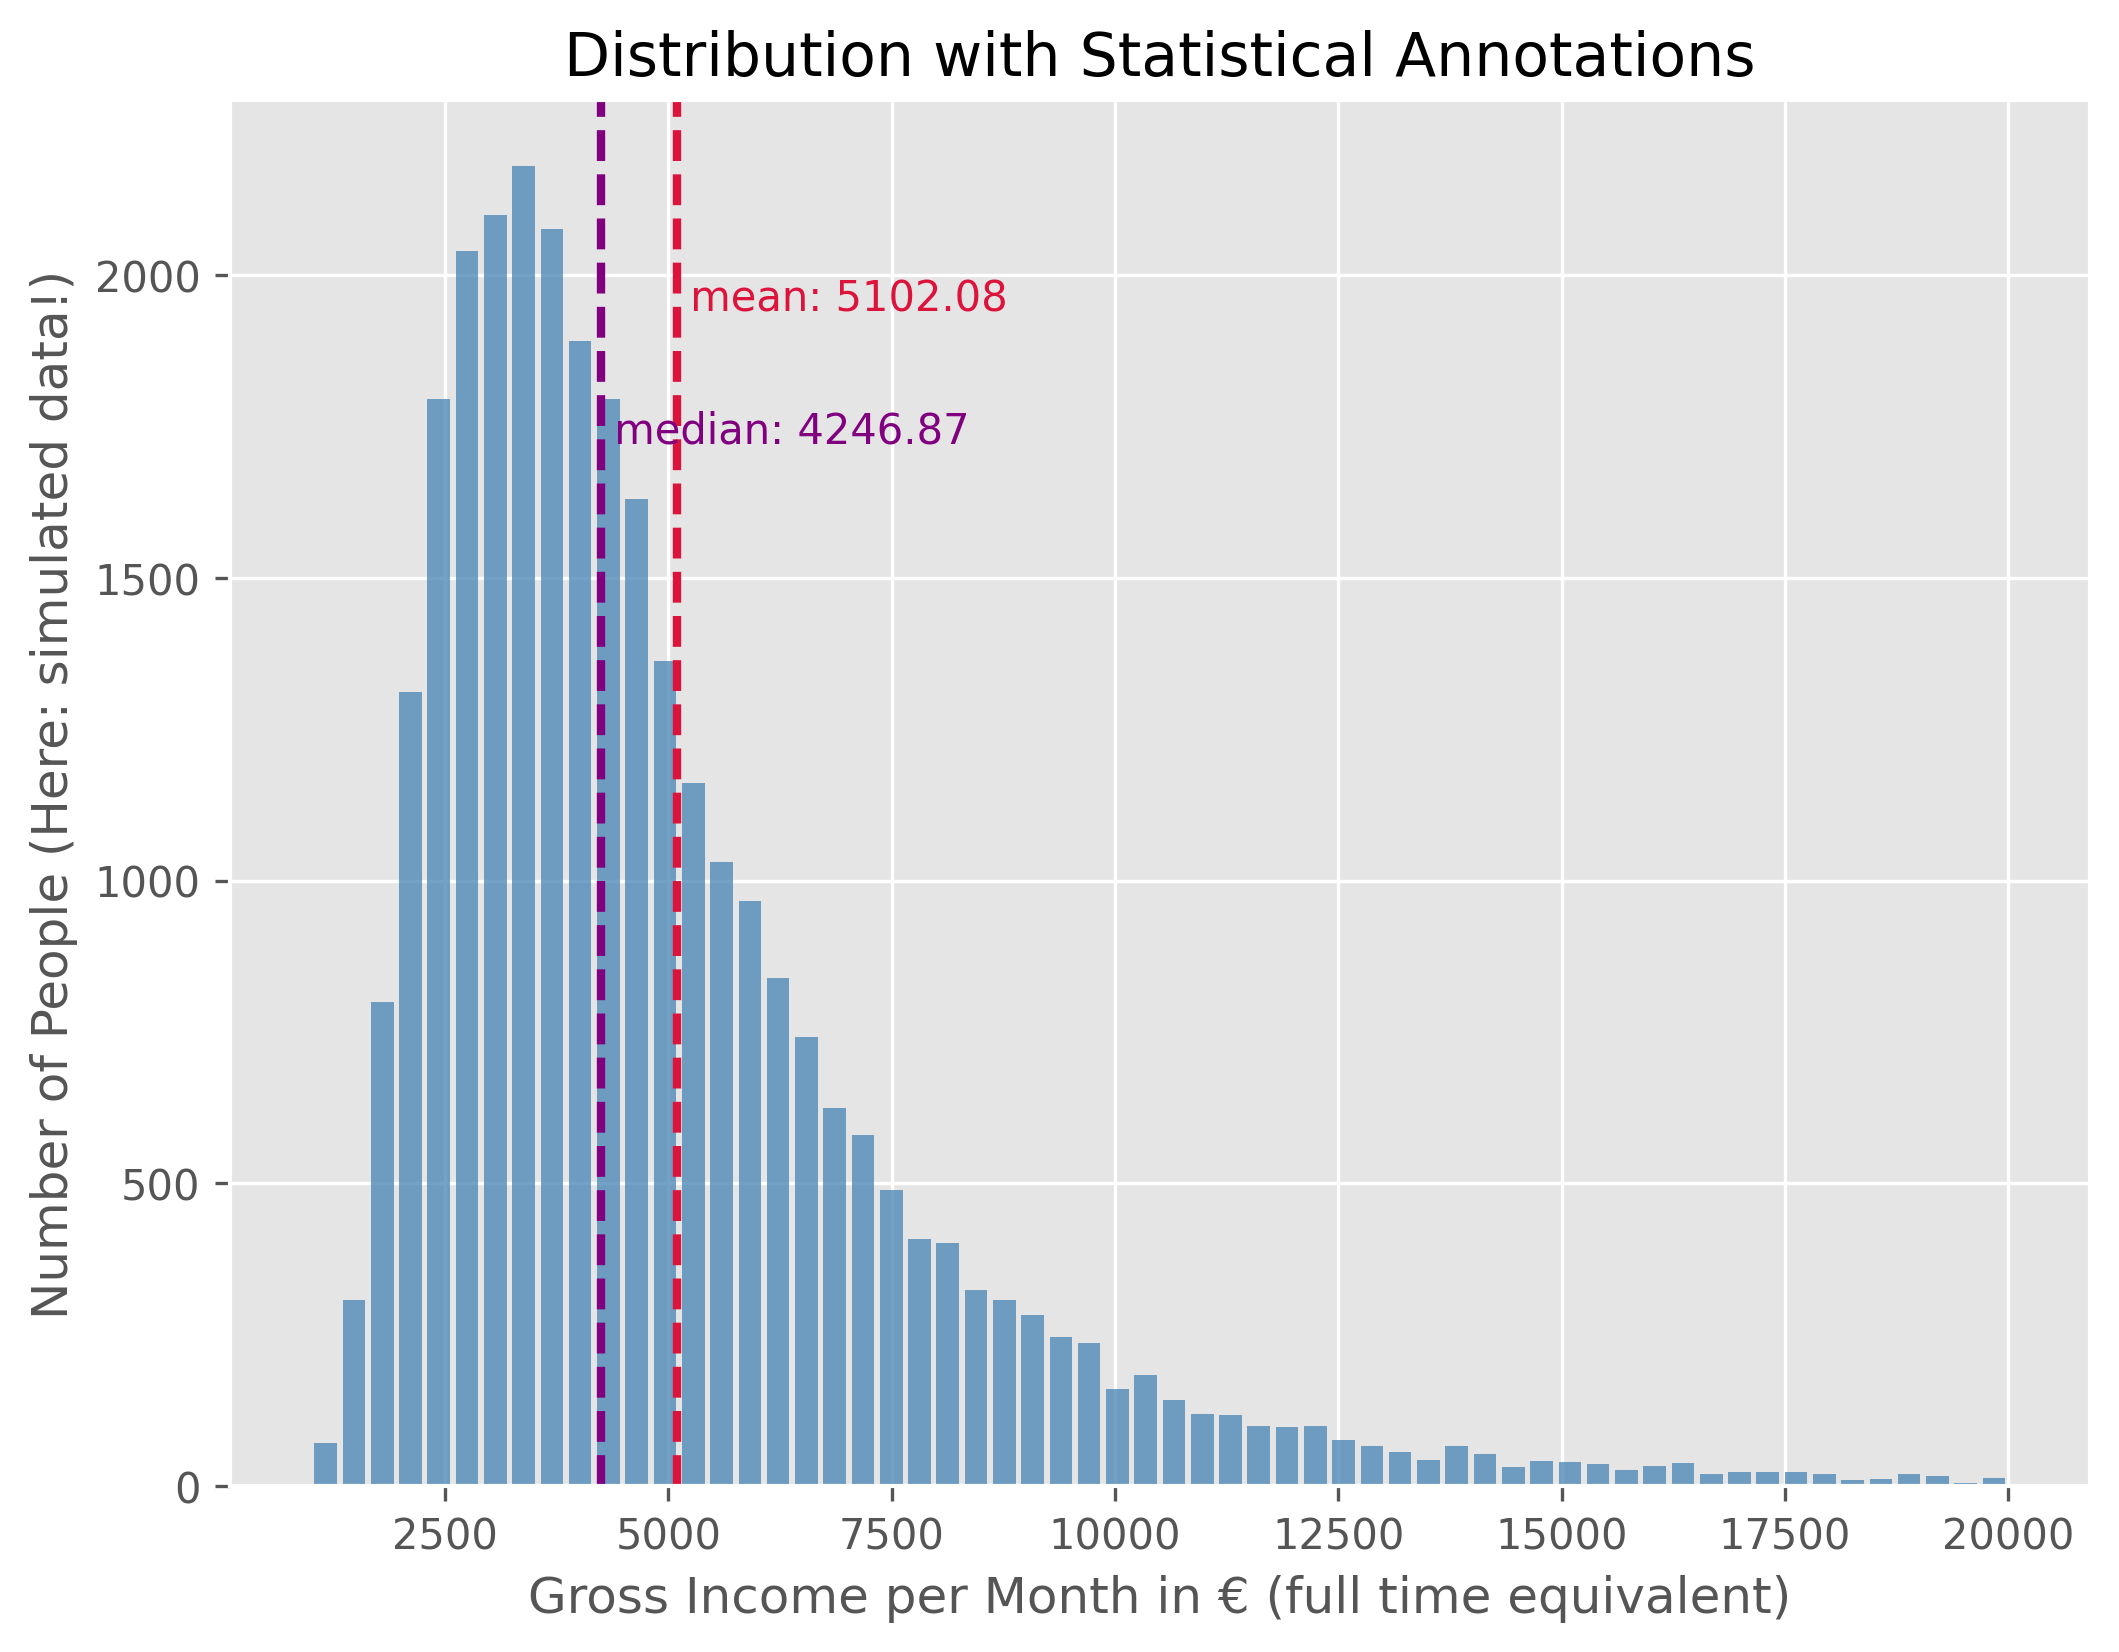

In [ ]:
# Plot the income values

# The visualization will depict income ranges and their frequencies.
plot_dist(income_simulated["income"], 60, ["mean", "median"], upper_bound=20_000)
plt.ylabel("Number of People (Here: simulated data!)")
plt.xlabel("Gross Income per Month in € (full time equivalent)")
plt.show()

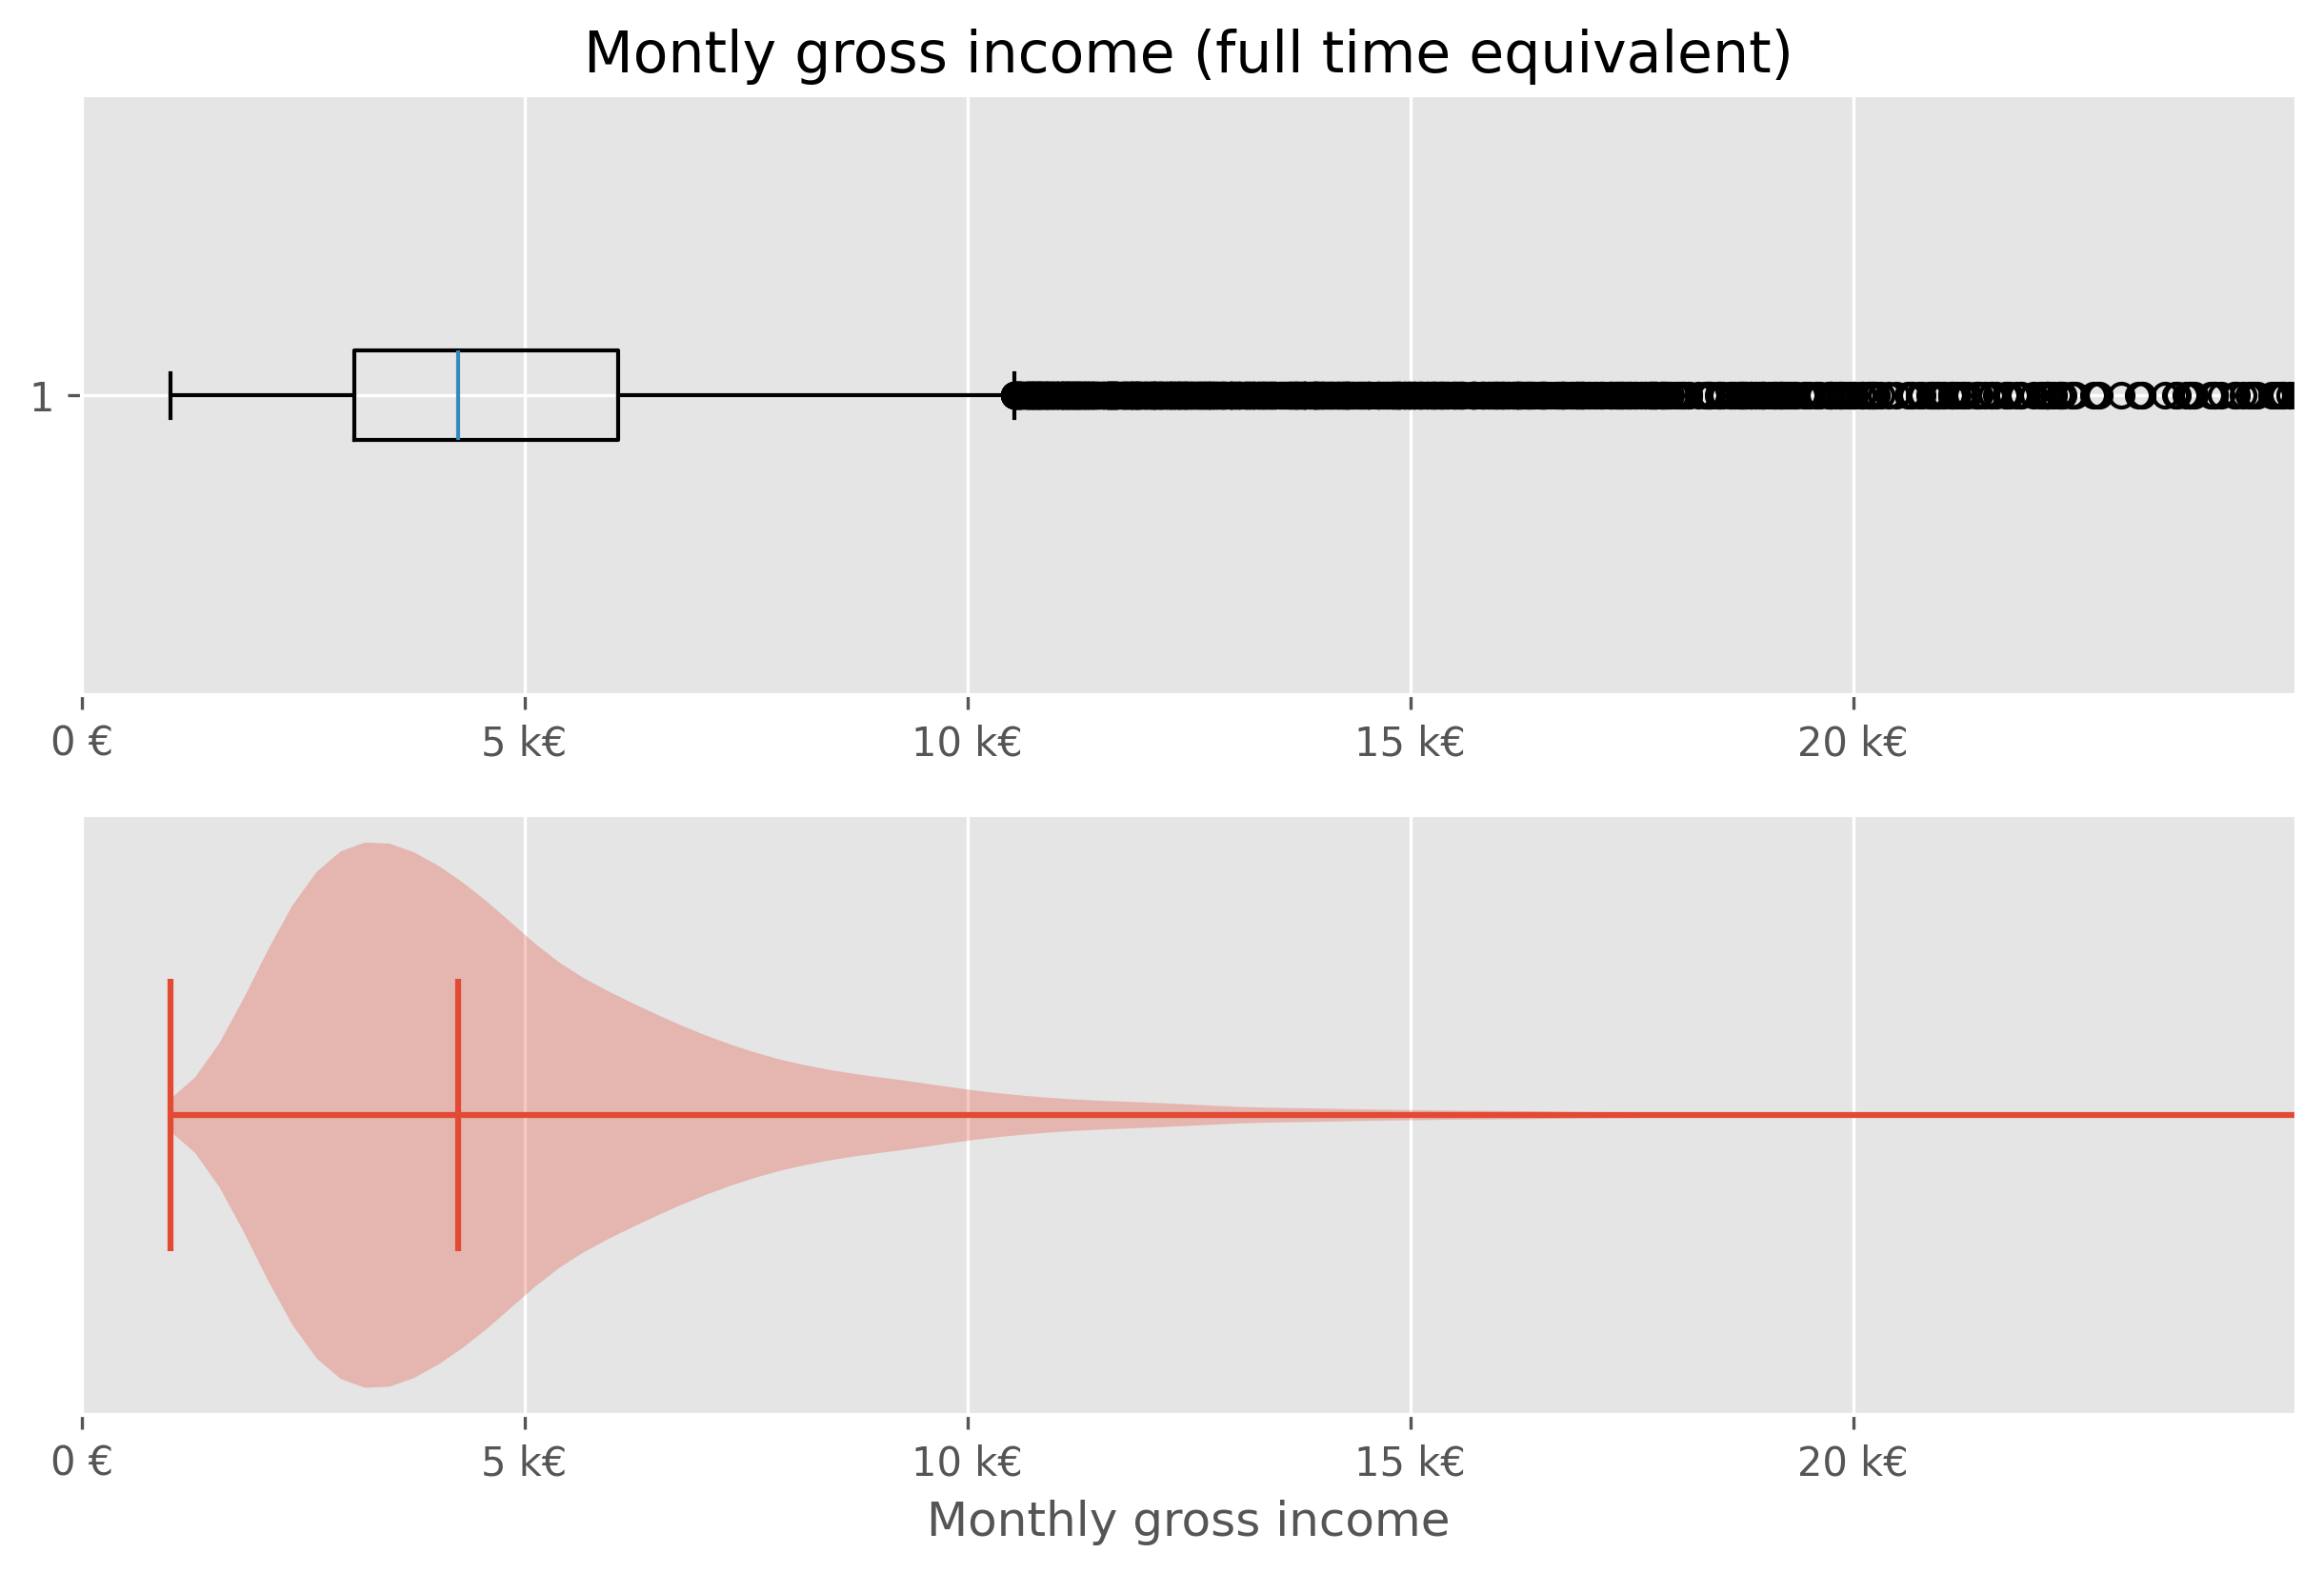

In [ ]:
# Boxplots and Violin Plots

fig, axes = plt.subplots(2, 1, figsize=(10, 6), dpi=300)

axes[0].set_title("Montly gross income (full time equivalent)")

# Plot 1 - Boxplot
axes[0].boxplot(income_simulated["income"], vert=False)
axes[0].set_xlim(0, 25_000)
#axes[0].set_xlabel("Monthly gross income")
axes[0].set_xticks(ticks = [0, 5000, 1e4, 1.5e4, 2e4],
              labels=["0 €", "5 k€","10 k€", "15 k€", "20 k€"])

# Plot 2 - Violinplot
axes[1].violinplot(income_simulated["income"], vert=False,
                   points=300,
                   showmedians=True)
axes[1].set(yticks=[])
axes[1].set_xlim(0, 25_000)
axes[1].set_xlabel("Monthly gross income")
axes[1].set_xticks(ticks = [0, 5000, 1e4, 1.5e4, 2e4],
              labels=["0 €", "5 k€","10 k€", "15 k€", "20 k€"])

plt.show()

## Filling the Space
The main issue is that the largest part of the figure essential shows virtually nothing (violin plot), or nothing readable (box plot).

Specifically in cases like this, it is often helpful to work with percentiles (or deciles, quintiles...).

General process:
- Order the data in increasing order
- Determine relevant percentiles
- Group data into percentile ranges
- Summarize data within each percentile
- Visualize the results


In [ ]:
# Code to compute and display quantiles of the income data
income_simulated.quantile(q=np.arange(0, 1.1, 0.1))

,income
0.0,1006.255723
0.1,2373.861557
0.2,2855.525994
0.3,3300.041220
0.4,3754.029137
0.5,4246.873829
0.6,4805.053872
0.7,5571.647341
0.8,6657.838875
0.9,8673.941898


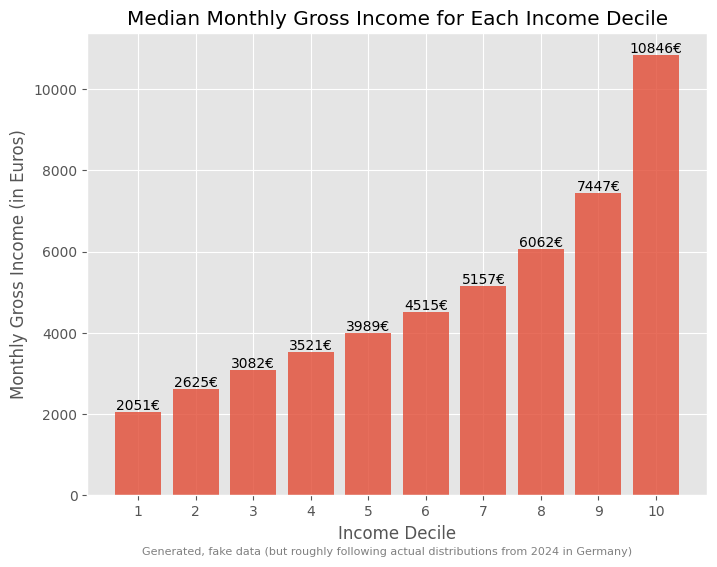

In [ ]:
# Create a grouping variable based on 'deciles'
income_simulated["decile"] = pd.qcut(income_simulated['income'], q=10, labels=np.arange(10))

# Code to visualize the median income for each decile
fig, ax = plt.subplots(figsize=(8,6))
ax.bar(x=np.arange(10), height=income_simulated.groupby("decile", observed=True).median()["income"],
       alpha=0.8,
      )
for i, v in enumerate(income_simulated.groupby("decile", observed=True).median()["income"]):
    ax.text(i, v + 50, f"{v:.0f}€", color='black', ha="center")

ax.set_xticks(ticks=np.arange(10), labels=np.arange(1,11), rotation=0)
ax.set_xlabel("Income Decile")
ax.set_ylabel("Monthly Gross Income (in Euros)")
ax.set_title("Median Monthly Gross Income for Each Income Decile")
fig.text(0.5, 0.01, "Generated, fake data (but roughly following actual distributions from 2024 in Germany)",
         ha="center", fontsize=8, color="gray")

plt.show()

In [ ]:
# Code to determine and display the perecentage of total income for each decile
income_sum = income_simulated.groupby("decile", observed=True).sum()
income_sum["income_percentage"] = income_sum["income"]*100/(income_sum["income"].sum()) # '*=' is a special operator, effectively means 'x = x*y'
income_sum

,income,income_percentage
decile,,
0,5.979132e+06,3.906335
1,7.859533e+06,5.134855
2,9.245522e+06,6.040360
3,1.056618e+07,6.903185
4,1.197309e+07,7.822355
5,1.355774e+07,8.857654
6,1.551004e+07,10.133147
7,1.825418e+07,11.925972
8,2.258159e+07,14.753187


## Distributions and Statistical Significance

Picking the correct data summary is important in the process of telling the story of our data.

It is important to remember two key aspects of these summary statistics:
1. They are (probably) **random**.
2. They are (probably) **wrong**.

Statistical distributions provide a structured way to visualize data variability, understand randomness, and capture the likelihood of different outcomes.

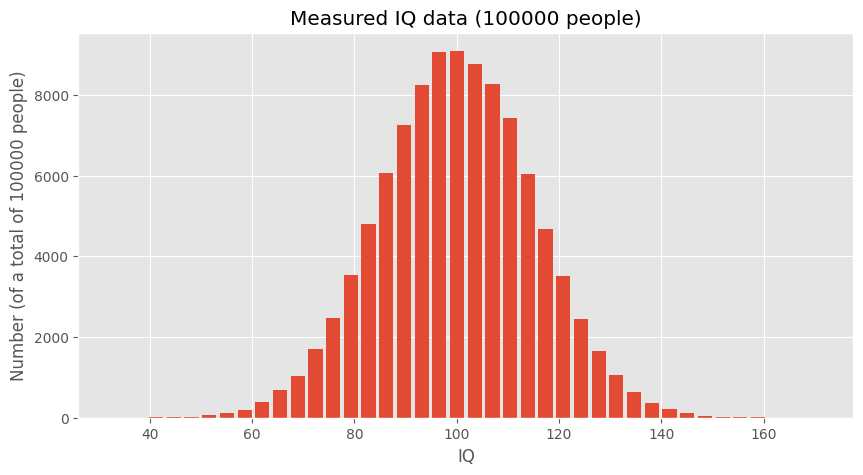

In [ ]:
# Create some artifical data

# Creating a random number generator with a fixed seed for reproducibility
rng = np.random.default_rng(seed=0)

# Generating a large dataset of IQ scores centered around the mean of 100 with a standard deviation of 15
data_iq_large = rng.normal(100, 15, 100000)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(data_iq_large, 40, rwidth=0.8)
ax.set_title("IQs")
ax.set_xlabel("IQ")
ax.set_ylabel(f"Number (of a total of {len(data_iq_large)} people)")
ax.set_title(f"Measured IQ data ({len(data_iq_large)} people)")

plt.show()


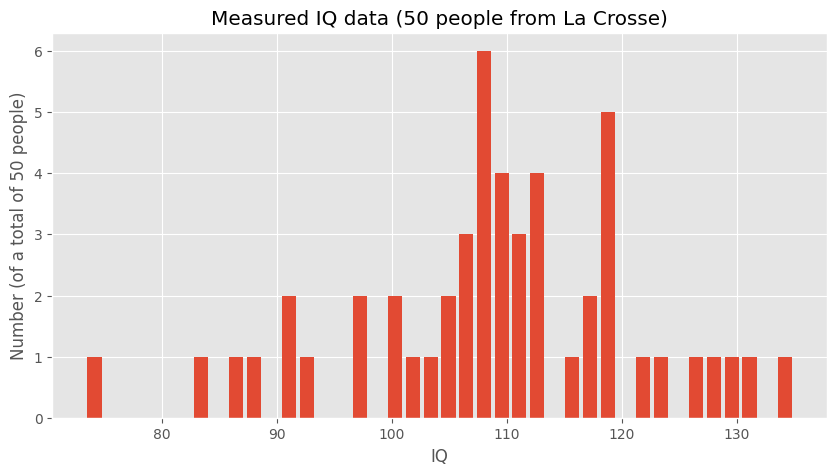

In [ ]:
# Create some localized artificial data

# Generating a smaller dataset for a specific group from La Crosse
data_iq_lacrosse = rng.normal(110, 15, 50)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(data_iq_lacrosse, 40, rwidth=0.8)
ax.set_title("IQs")
ax.set_xlabel("IQ")
ax.set_ylabel(f"Number (of a total of {len(data_iq_lacrosse)} people)")
ax.set_title(f"Measured IQ data ({len(data_iq_lacrosse)} people from La Crosse)")

plt.show()

## Testing Equality of Means

For our IQ example, suppose we have two independent samples and are interested in determining if La Crosse residents have higher IQs than the general population.

We need to translate this to a testable (falsifiable) statement. If we are comfortable using *means* as a summary statistic, then we could state something like $$\mu_{overall} = \mu_{La Crosse}$$ where $\mu$ represents a population average.

There are several ways to state (with certainty) whether two groups differ based on their means.  The best known is the **t-test**.



In [ ]:
# Importing the necessary function from scipy.stats
from scipy.stats import ttest_ind

# Conducting the t-test between the large dataset and the La Crosse dataset
test_output = ttest_ind(data_iq_large, data_iq_lacrosse)

# Output the results of the t-test
print(f"T-Statistic: {test_output.statistic}")
print(f"P-Value: {test_output.pvalue}")
print("Confidence interval:", test_output.confidence_interval()) #note the method call

T-Statistic: -4.201608996012756
P-Value: 2.6525398189088037e-05
Confidence interval: ConfidenceInterval(low=np.float64(-13.074761999336825), high=np.float64(-4.756667216725989))


## Using Distributions

The t-test above provides a broad summary of the data...with caveats. Interpretations of these results are easy to state incorrectly!

- Test Statistic (t): effectively a scaled distance metric, based on sample means and standard deviations (how far apart average IQs are in sample data, divided by a measure of standard deviation)
- P-value: chance we would see data as extreme or more extreme than our sample data, if the null hypothesis is true (that there is no difference in average IQs, for example)
- Confidence: 95% (or other percentages) of created intervals from repeated sampling would contain the true population parameter (difference in means for the IQ example)

Within the p-value and confidence interval calculations, there is an implicit reference to a theoretical distribution (namely, Student's T distribution). When using these metrics, we are effectively stating that we are comfortable with invoking the Central Limit Theorem. Remember that thing?

## That's abnormal...

What if you're not comfortable invoking the Central Limit Theorem?

There are a variety of 'non-parametric' alternatives to many of the standard approaches in Statistics. These include bootstrapping, permutation or randomization testing, or index-based methods.

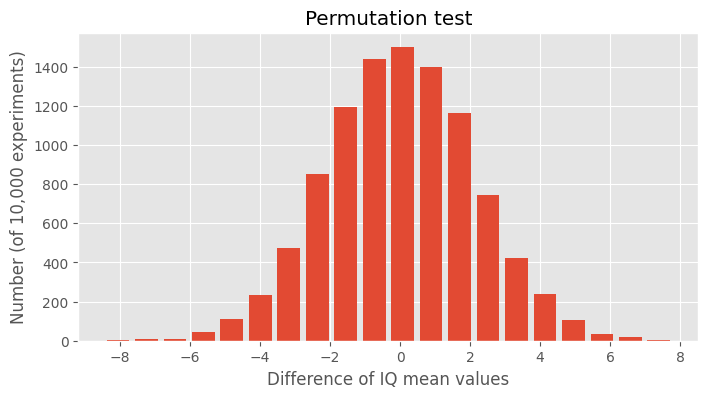

In [ ]:
# The following Python code defines a function to perform permutation testing by randomly sampling the data, and then it carries out the test multiple times to create a distribution of the differences in means:

def permutation_distance(data, n_samples):
    """Calculate the difference in means between the original data and a random subset."""
    return data.mean() - np.random.choice(data, n_samples).mean()

# Generating permutation experiments
permutation_experiments = [permutation_distance(data_iq_large, 50) for _ in range(10000)]
# Plotting the results of the permutation experiments
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(permutation_experiments, 20, rwidth=0.8)
ax.set_title("Permutation test")
ax.set_xlabel("Difference of IQ mean values")
ax.set_ylabel("Number (of 10,000 experiments)")
plt.show()